# Visualizar el dataset — X Ray (HackSpain 2026)

Recorrido visual por los nueve CSV del reto, tabla a tabla, para que todo el equipo vea **lo mismo** antes de construir features y score.

Reglas del notebook (ver [`notebooks/README.md`](README.md)):

- Carga con `xray.data.load()` (caché parquet en `artifacts/raw/`, ~5 s una vez cacheado). Nada de rutas absolutas.
- No define pipeline: solo agrega y pinta. §1–§8 recorren las tablas; §9–§15 calculan las **señales** del índice de estado como *preview* de `xray.features` y `xray.labels` (slices #2–#4).
- Sin outputs en git (`nbstripout`).

Cada gráfico va precedido de su **tabla** (la misma agregación que se pinta): es la vista accesible y lo que se copia a la doc.

## 0. Estilo

Paleta y anatomía fijas para todo el notebook, con un único criterio: **el color hace un solo trabajo por gráfico**.

| Trabajo | Regla | Aquí |
|---|---|---|
| Identidad (series distintas) | hues fijos en orden, nunca reciclados | `SERIES[0..n]` + leyenda |
| Magnitud (cuánto) | un hue, claro → oscuro | `CMAP_SEQ` (azul) |
| Polaridad (entradas/salidas, ± saldo) | dos hues opuestos + neutro | `DIV` (azul ↔ rojo) |
| Una categoría nominal con muchas barras | **un solo color** (la longitud ya codifica el valor) | `SERIES[0]` |
| Contexto ("Otros", "sin dato") | gris de de-énfasis | `GRAY` |

Paleta validada con `validate_palette.py` (skill *dataviz*) sobre superficie blanca `#ffffff`, la del notebook: banda de luminosidad, croma, separación CVD (peor par adyacente ΔE 9,1 protan) y visión normal (ΔE 19,6) **pasan**; aqua/amarillo/magenta quedan por debajo de 3:1 de contraste → por eso cada gráfico lleva su tabla al lado (canal de relevo). Rampa azul: monótona, saltos ≥ 0,06 L.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40, "display.width", 160, "display.float_format", "{:,.2f}".format)

# --- paleta (references/palette.md de la skill dataviz; modo claro, superficie blanca)
SURFACE = "#ffffff"
INK = dict(primary="#0b0b0b", secondary="#52514e", muted="#898781", grid="#e1e0d9", axis="#c3c2b7")
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GRAY = "#c3c2b7"                                            # de-énfasis (contexto)
DIV = dict(neg="#e34948", mid="#f0efec", pos="#2a78d6")     # polaridad: rojo ↔ azul
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_SEQ = LinearSegmentedColormap.from_list("xray_blue", [SURFACE] + SEQ)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "axes.edgecolor": INK["axis"], "axes.linewidth": 1, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": INK["grid"], "grid.linewidth": 1, "grid.linestyle": "-",
    "axes.axisbelow": True, "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9, "xtick.major.size": 0, "ytick.major.size": 0,
    "axes.labelcolor": INK["secondary"], "axes.labelsize": 9,
    "axes.titlecolor": INK["primary"], "axes.titlesize": 11.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "text.color": INK["primary"], "legend.frameon": False, "legend.fontsize": 9, "legend.labelcolor": INK["secondary"],
    "lines.linewidth": 2, "lines.solid_joinstyle": "round", "lines.solid_capstyle": "round",
})

FULL_MONTHS = pd.period_range("2024-09", "2026-08", freq="M")   # 2026-09 solo trae el día 1


def fmt_k(x, _=None):
    # cifras compactas: 1,284 · 13K · 4.2M
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    a = abs(x)
    if a >= 1e9:
        return f"{x/1e9:,.1f}B"
    if a >= 1e6:
        return f"{x/1e6:,.1f}M"
    if a >= 1e4 or (a >= 1e3 and a % 1000 == 0):
        return f"{x/1e3:,.0f}K"
    return f"{x:,.0f}"


KFMT = FuncFormatter(fmt_k)
PCT = FuncFormatter(lambda x, _: f"{x:.0%}")
PLAIN = FuncFormatter(lambda x, _: f"{x:,.0f}")


def title(ax, text, sub=None):
    # título a la izquierda + subtítulo en tinta secundaria
    ax.set_title(text, pad=22 if sub else 10)
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=9, color=INK["secondary"], va="bottom")


def hbars(ax, labels, values, color=SERIES[0], label_top=3, fmt=fmt_k, xfmt=KFMT):
    # barras horizontales finas; categoría nominal = un color; etiqueta solo las `label_top` mayores
    values = np.asarray(values, dtype=float)
    y = np.arange(len(labels))[::-1]
    ax.barh(y, values, height=0.6, color=color)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    ax.spines["left"].set_visible(False)
    ax.xaxis.set_major_formatter(xfmt)
    for i in np.argsort(values)[::-1][:label_top]:
        ax.text(values[i], y[i], " " + fmt(values[i]), va="center", ha="left", fontsize=9, color=INK["secondary"])
    ax.set_xlim(0, values.max() * 1.15)


def cols(ax, x, values, color=SERIES[0], width=0.6):
    # columnas finas: el aire entre vecinas hace de separador
    return ax.bar(x, values, width=width, color=color)


def cap_label(ax, x, y, text):
    # valor sobre la cabeza de una columna
    ax.annotate(text, (x, y), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
                fontsize=9, color=INK["secondary"])


def end_label(ax, x, y, text, color=INK["secondary"]):
    ax.annotate(text, (x, y), xytext=(6, 0), textcoords="offset points", va="center", ha="left",
                fontsize=9, color=color)


def end_labels(ax, x, ys, texts, min_gap=0.06):
    # etiquetas de fin de línea; si dos series terminan demasiado cerca, se dejan a la leyenda
    lo, hi = ax.get_ylim()
    ys = np.asarray(ys, dtype=float)
    if len(ys) > 1 and np.min(np.diff(np.sort(ys))) < min_gap * (hi - lo):
        return
    for y, t in zip(ys, texts):
        end_label(ax, x, y, t)


def marker(**kw):
    # marcador ≥ 8 px con anillo de 2 px del color de la superficie
    return dict(marker="o", markersize=8, markeredgecolor=SURFACE, markeredgewidth=2) | kw


def median_line(ax, value, text):
    ax.axvline(value, color=INK["primary"], linewidth=1)
    ax.text(value, 0.96, " " + text, transform=ax.get_xaxis_transform(), fontsize=9, color=INK["secondary"], va="top")


def kpi_row(items):
    # fila de stat tiles: (etiqueta, valor[, nota]); el número es el gráfico
    fig, axes = plt.subplots(1, len(items), figsize=(2.4 * len(items), 1.25))
    for ax, it in zip(np.atleast_1d(axes), items):
        label, value, *note = it
        ax.axis("off")
        ax.text(0, 0.95, label, fontsize=9, color=INK["secondary"], va="top")
        ax.text(0, 0.50, value, fontsize=20, fontweight="semibold", color=INK["primary"], va="center")
        if note:
            ax.text(0, 0.08, note[0], fontsize=8.5, color=INK["muted"], va="bottom")
    fig.tight_layout(pad=0.4)
    return fig


def month_ticks(ax, months, every=3):
    # eje x con periodos mensuales: etiqueta uno de cada `every`
    idx = np.arange(len(months))
    ax.set_xticks(idx[::every], [str(m) for m in months[::every]])
    return idx


def stacked_share(ax, table, colors=None, legend_ncol=4):
    # barra apilada horizontal (parte de un todo): una fila por índice, un color por columna,
    # hueco de 2 px entre segmentos, etiqueta dentro solo si cabe; los valores exactos van en la tabla
    colors = colors or SERIES
    n = len(table)
    for r, (_, row) in enumerate(table.iterrows()):
        left = 0
        for i, (name, v) in enumerate(row.items()):
            ax.barh([n - 1 - r], [v], left=left, height=0.5, color=colors[i], edgecolor=SURFACE,
                    linewidth=2, label=name if r == 0 else None)
            if v > 0.07:
                dark_fill = colors[i] in (SERIES[0], SERIES[5], SERIES[6], SERIES[7])
                ax.text(left + v / 2, n - 1 - r, f"{v:.0%}", ha="center", va="center", fontsize=9,
                        color=SURFACE if dark_fill else INK["primary"])
            left += v
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.4, n - 0.4 + 0.6)
    ax.set_yticks(range(n - 1, -1, -1), table.index)
    ax.set_xticks([])
    ax.grid(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_visible(False)
    ax.legend(loc="upper left", bbox_to_anchor=(0, 0.12), ncol=legend_ncol, handlelength=1.2)

## 1. Carga y tamaño

Nueve tablas. `transactions` y `invoices` son las grandes; el resto son catálogos.

In [2]:
from xray.data import load

t = load()
groups, companies, bank, debt, dsc, tx, inv, bal = (
    t[k] for k in ["groups", "companies", "banking_products", "debt_products",
                   "debt_schedule_config", "transactions", "invoices", "balances"]
)
pd.DataFrame({"filas": {k: len(v) for k, v in t.items()},
              "columnas": {k: v.shape[1] for k, v in t.items()}})

,filas,columnas
groups,250,3
companies,1286,6
banking_products,5987,8
debt_products,2239,11
debt_schedule_config,87,14
transactions,2556437,13
invoices,897894,15
balances,7996,8


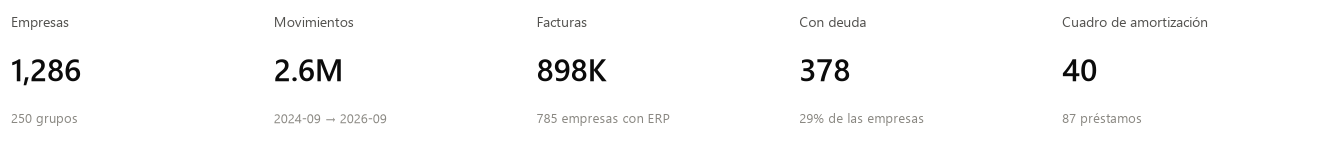

In [3]:
n_with_debt = debt["company_id"].nunique()
n_with_inv = inv["company_id"].nunique()
kpi_row([
    ("Empresas", f"{len(companies):,}", f"{len(groups)} grupos"),
    ("Movimientos", fmt_k(len(tx)), "2024-09 → 2026-09"),
    ("Facturas", fmt_k(len(inv)), f"{n_with_inv:,} empresas con ERP"),
    ("Con deuda", f"{n_with_debt:,}", f"{n_with_debt/len(companies):.0%} de las empresas"),
    ("Cuadro de amortización", f"{dsc['company_id'].nunique()}", f"{len(dsc)} préstamos"),
]);

## 2. Cobertura temporal

Lo que condiciona todo (plan §5): **mediana 19 meses de historia; un 25 % de empresas con ≤ 10 meses**. Las ventanas de 3/6 meses son obligatorias y los features tienen que degradar bien.

El mapa de calor es la foto completa: una fila por empresa (ordenadas por su primer mes con movimientos), una columna por mes, color = movimientos en ese mes (escala log, un solo hue: es *magnitud*).

In [4]:
act = (tx.groupby(["company_id", "month"]).size().unstack(fill_value=0)
         .reindex(columns=pd.period_range("2024-09", "2026-09", freq="M"), fill_value=0))
first = act.gt(0).idxmax(axis=1)
n_months = act.gt(0).sum(axis=1)
act = act.loc[pd.DataFrame({"first": first, "n": -n_months}).sort_values(["first", "n"]).index]

coverage = pd.DataFrame({"empresas activas": act.gt(0).sum(), "movimientos": act.sum()})
coverage.T

,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
empresas activas,439,470,476,520,648,684,717,742,762,777,829,842,890,933,960,1019,1153,1217,1223,1229,1216,1205,1199,1163,866
movimientos,41975,49521,44730,48178,61961,61678,71859,77155,79439,83975,97619,85031,101442,110678,99263,114764,130699,147951,182783,176180,166696,177661,185290,150667,9242


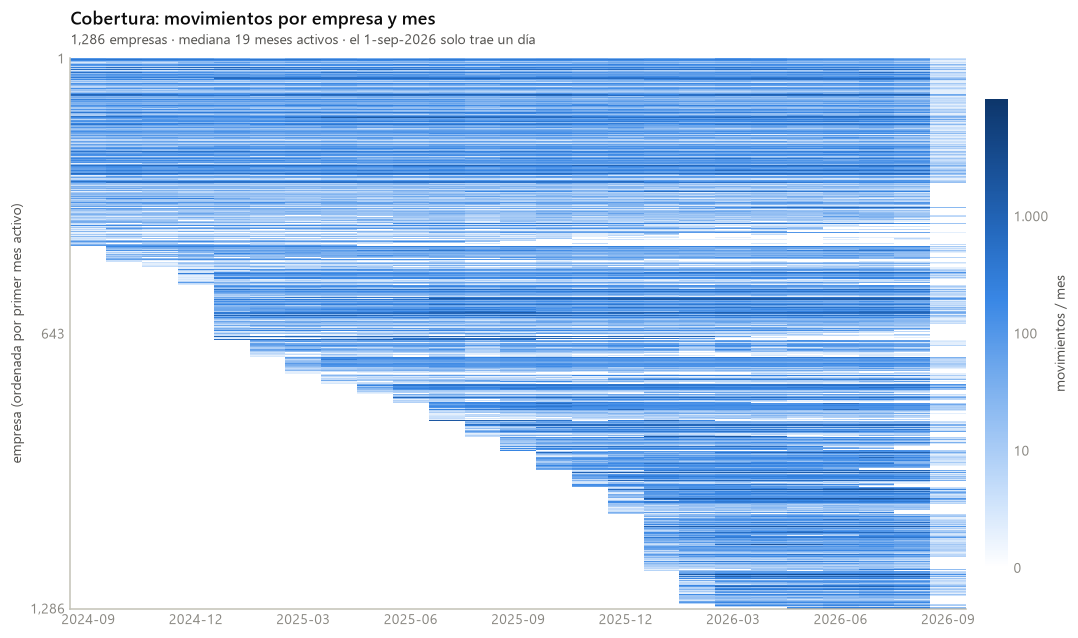

In [5]:
fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(np.log10(act.values + 1), aspect="auto", cmap=CMAP_SEQ, interpolation="nearest")
month_ticks(ax, act.columns, every=3)
ax.set_yticks([0, len(act) // 2, len(act) - 1], ["1", f"{len(act)//2}", f"{len(act):,}"])
ax.set_ylabel("empresa (ordenada por primer mes activo)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_ticks([0, 1, 2, 3], labels=["0", "10", "100", "1.000"])
cb.outline.set_visible(False)
cb.set_label("movimientos / mes", color=INK["secondary"])
title(ax, "Cobertura: movimientos por empresa y mes",
      f"{len(act):,} empresas · mediana {int(n_months.median())} meses activos · el 1-sep-2026 solo trae un día")
plt.show()

In [6]:
hist_months = n_months.value_counts().sort_index()
hist_months.to_frame("empresas").T

,1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
empresas,1,5,6,32,102,131,61,39,50,34,49,38,31,30,26,52,36,108,38,24,102,291


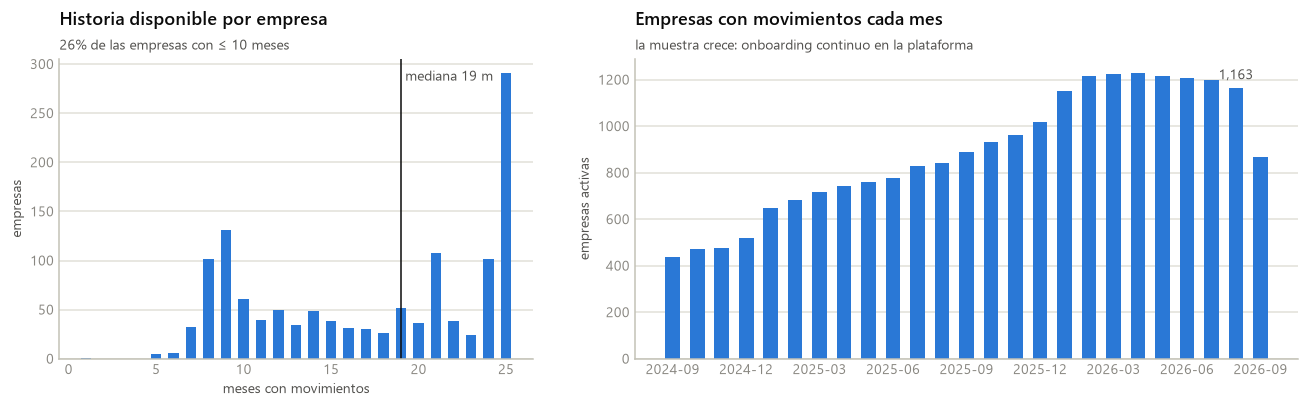

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.4]})

ax = axes[0]
cols(ax, hist_months.index, hist_months.values)
median_line(ax, n_months.median(), f"mediana {int(n_months.median())} m")
ax.set_xlabel("meses con movimientos")
ax.set_ylabel("empresas")
title(ax, "Historia disponible por empresa", f"{(n_months <= 10).mean():.0%} de las empresas con ≤ 10 meses")

ax = axes[1]
active = coverage["empresas activas"]
idx = month_ticks(ax, active.index, every=3)
cols(ax, idx, active.values)
cap_label(ax, idx[-2], active.iloc[-2], f"{active.iloc[-2]:,}")
ax.set_ylabel("empresas activas")
title(ax, "Empresas con movimientos cada mes", "la muestra crece: onboarding continuo en la plataforma")
fig.tight_layout(w_pad=3)
plt.show()

## 3. Estructura: grupos, países, ERP

Sin campo sector y `country` solo al 18 % → los pares de comparación saldrán por tamaño y patrón de flujos, no por sector.

In [8]:
gsize = groups["n_companies_in_sample"].value_counts().sort_index()
erp = groups["erp"].fillna("(sin ERP)").value_counts()
erp_top = pd.concat([erp.iloc[:6], pd.Series({"Otros": erp.iloc[6:].sum()})])
pd.DataFrame({"grupos por tamaño": gsize}).T

n_companies_in_sample,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22
grupos por tamaño,71,34,27,22,15,15,9,7,6,4,6,7,7,1,3,3,2,4,2,2,3


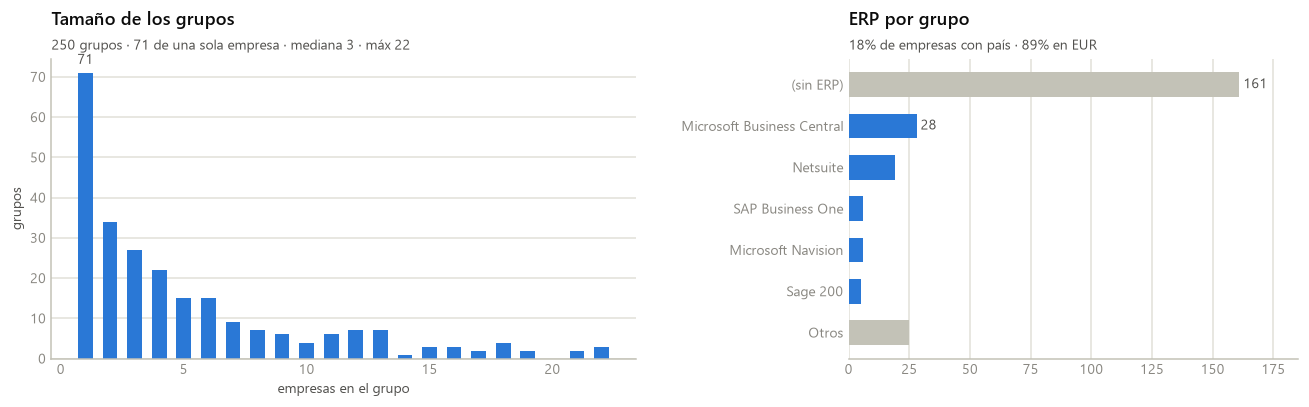

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
cols(ax, gsize.index, gsize.values)
cap_label(ax, gsize.index[0], gsize.iloc[0], f"{gsize.iloc[0]}")
ax.set_xlabel("empresas en el grupo")
ax.set_ylabel("grupos")
title(ax, "Tamaño de los grupos",
      f"{len(groups)} grupos · {gsize.iloc[0]} de una sola empresa · mediana {int(groups['n_companies_in_sample'].median())} · máx {gsize.index.max()}")

ax = axes[1]
hbars(ax, erp_top.index.tolist(), erp_top.values, color=[GRAY] + [SERIES[0]] * 5 + [GRAY], label_top=2, xfmt=PLAIN)
title(ax, "ERP por grupo",
      f"{companies['country'].notna().mean():.0%} de empresas con país · {(companies['currency']=='EUR').mean():.0%} en EUR")
fig.tight_layout(w_pad=3)
plt.show()

## 4. Transacciones

2,56 M de movimientos bancarios. Tres preguntas: **cuánto entra y sale cada mes** (polaridad → azul/rojo), **qué categorías** trae el banco (nominal → un color) y **cuánto está conciliado** (parte de un todo).

Dos trampas para los agregados:

- Los importes están en la **moneda de la empresa, sin convertir** (hay COP y MXN con facturas de 10⁹–10¹⁰). Aquí solo se agregan empresas en EUR (89 %).
- Diez empresas concentran el 73 % del volumen bruto (barridos de tesorería de 10⁹ €/mes). Por eso se pinta la **empresa mediana**, no la suma.

Y además: el 25 % de movimientos viene sin categoría (`-`) y `counterparty_id` solo al 10 % — la concentración de clientes se calcula desde facturas, no desde aquí.

In [10]:
eur_companies = companies.loc[companies["currency"] == "EUR", "company_id"]
tx_eur = tx[tx["company_id"].isin(eur_companies)]

cm = (tx_eur.assign(entradas=tx_eur["amount"].clip(lower=0), salidas=tx_eur["amount"].clip(upper=0))
            .groupby(["company_id", "month"])[["entradas", "salidas"]].sum())
cm["neto"] = cm["entradas"] + cm["salidas"]
flows = cm.groupby("month").median().reindex(FULL_MONTHS)      # empresa mediana, mes a mes
flows.tail(6)

,entradas,salidas,neto
2026-03,"192,244.04","-198,471.05",-1.27
2026-04,"198,443.98","-234,465.91",-274.78
2026-05,"185,526.63","-177,933.60",50.66
2026-06,"215,675.05","-211,789.58",-12.05
2026-07,"264,092.58","-279,097.80",-7.01
2026-08,"158,580.24","-160,376.67",0.00


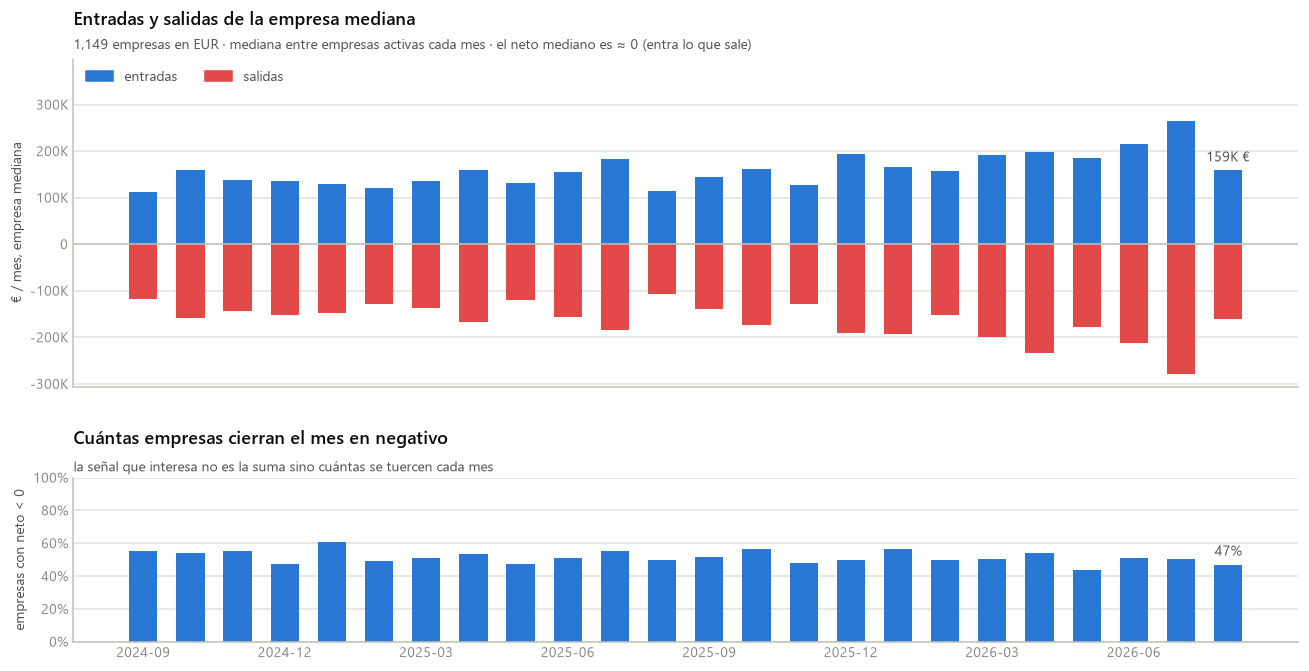

In [11]:
def flows_chart(ax, f, every=3, net=True):
    # columnas divergentes (entradas +, salidas −) y, opcionalmente, línea de neto en tinta
    idx = month_ticks(ax, f.index, every)
    cols(ax, idx, f["entradas"].values, color=DIV["pos"])
    cols(ax, idx, f["salidas"].values, color=DIV["neg"])
    handles = [mpl.patches.Patch(color=DIV["pos"], label="entradas"),
               mpl.patches.Patch(color=DIV["neg"], label="salidas")]
    if net:
        ax.plot(idx, f["neto"].values, color=INK["primary"], linewidth=1.5, **marker(markersize=5))
        handles.append(mpl.lines.Line2D([], [], color=INK["primary"], marker="o", markersize=5, label="neto"))
    ax.axhline(0, color=INK["axis"], linewidth=1)
    ax.yaxis.set_major_formatter(KFMT)
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.18 * (hi - lo))          # aire para la leyenda
    ax.legend(handles=handles, loc="upper left", ncol=3)
    return idx


def balance_line(ax, x, b, ms=8):
    # una serie (azul) con lavado al 10 %: azul sobre cero, rojo bajo cero (polaridad)
    ax.plot(x, b, color=SERIES[0], **marker(markersize=ms))
    ax.fill_between(x, b, 0, where=b >= 0, color=DIV["pos"], alpha=0.10, interpolate=True)
    ax.fill_between(x, b, 0, where=b < 0, color=DIV["neg"], alpha=0.10, interpolate=True)
    ax.axhline(0, color=INK["axis"], linewidth=1)


neg_share = cm["neto"].lt(0).groupby("month").mean().reindex(FULL_MONTHS)

fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
idx = flows_chart(ax, flows, net=False)
cap_label(ax, idx[-1], flows["entradas"].iloc[-1], fmt_k(flows["entradas"].iloc[-1]) + " €")
ax.set_ylabel("€ / mes, empresa mediana")
title(ax, "Entradas y salidas de la empresa mediana",
      f"{tx_eur['company_id'].nunique():,} empresas en EUR · mediana entre empresas activas cada mes · el neto mediano es ≈ 0 (entra lo que sale)")

ax = axes[1]
cols(ax, idx, neg_share.values)
cap_label(ax, idx[-1], neg_share.iloc[-1], f"{neg_share.iloc[-1]:.0%}")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 1)
ax.set_ylabel("empresas con neto < 0")
title(ax, "Cuántas empresas cierran el mes en negativo", "la señal que interesa no es la suma sino cuántas se tuercen cada mes")
fig.tight_layout(h_pad=2.5)
plt.show()

In [12]:
cat = (tx.assign(category=tx["category"].fillna("-").replace({"-": "(sin categoría)"}))
         .groupby("category").agg(movimientos=("amount", "size"), empresas=("company_id", "nunique"))
         .sort_values("movimientos", ascending=False))
cat.head(14)

,movimientos,empresas
category,,
(sin categoría),635860,1213
collection,567417,1259
payment,362276,1205
utility,259430,1123
fee,179500,1049
transfer,152102,925
bulk_collection,65492,263
tax,55904,1155
cash_settlement,48280,631


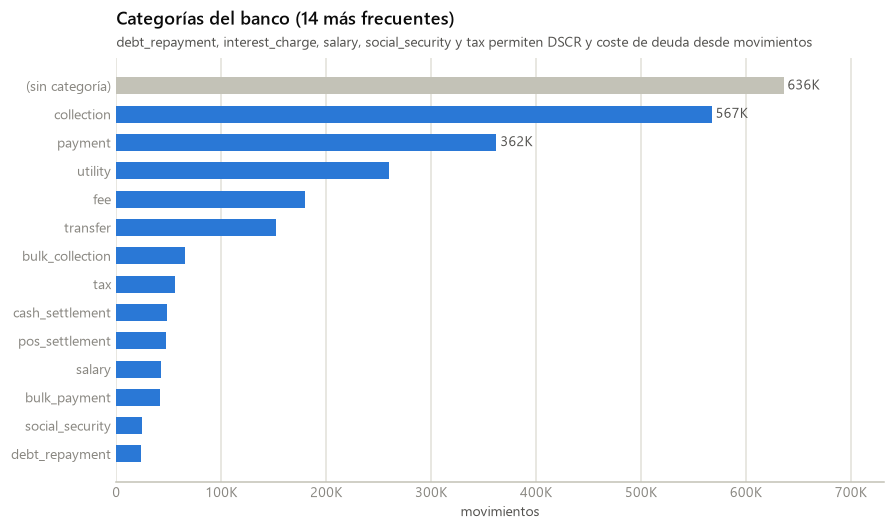

In [13]:
top = cat.head(14)
fig, ax = plt.subplots(figsize=(9, 5))
hbars(ax, top.index.tolist(), top["movimientos"].values, color=[GRAY] + [SERIES[0]] * 13, label_top=3)
ax.set_xlabel("movimientos")
title(ax, "Categorías del banco (14 más frecuentes)",
      "debt_repayment, interest_charge, salary, social_security y tax permiten DSCR y coste de deuda desde movimientos")
plt.show()

In [14]:
acc = tx["accounting_status"].fillna("(sin estado)").value_counts(normalize=True)
acc = pd.concat([acc.iloc[:4], pd.Series({"Otros": acc.iloc[4:].sum()})]).to_frame("movimientos").T
acc

,(sin estado),RECONCILIATION_COMPLETED,DISCARDED,PENDING,Otros
movimientos,0.62,0.21,0.12,0.04,0.02


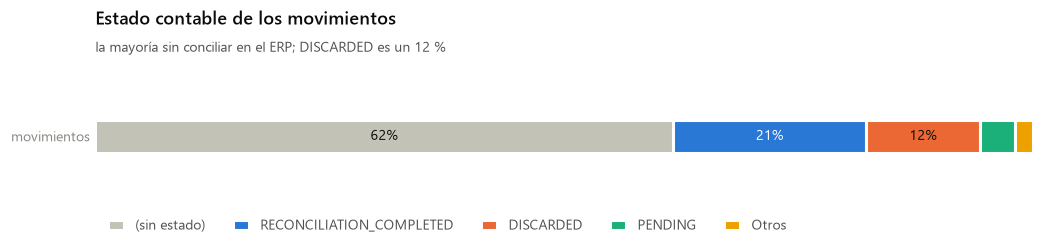

In [15]:
fig, ax = plt.subplots(figsize=(11, 2.0))
stacked_share(ax, acc, colors=[GRAY, SERIES[0], SERIES[1], SERIES[2], SERIES[3]], legend_ncol=5)
title(ax, "Estado contable de los movimientos", "la mayoría sin conciliar en el ERP; DISCARDED es un 12 %")
plt.show()

## 5. Facturas

Sin campo dirección: **signo del importe** (`xray.data` ya crea `direction`: negativo = recibida, positivo = emitida). Y ojo con `overdue` (21 %): `payment_date == due_date` en el 96 % → **no es una fecha real**. El retraso a proveedores se mide con `pending_amount` + `due_date`.

Igual que en §4: importes en moneda local (`currency`) y agregados dominados por pocas empresas → empresa mediana, solo facturas en EUR.

In [16]:
inv_eur = inv[(inv["currency"] == "EUR") & inv["direction"].notna() & inv["issuance_date"].notna()]
inv_cm = (inv_eur.assign(month=inv_eur["issuance_date"].dt.to_period("M"), a=inv_eur["amount"].abs())
                 .groupby(["company_id", "month", "direction"])["a"].sum().unstack("direction"))
inv_m = (inv_cm.groupby("month").median().reindex(FULL_MONTHS)
               .rename(columns={"issued": "emitidas", "received": "recibidas"}))
inv_m.tail(6)

direction,emitidas,recibidas
2026-03,"86,665.95","53,877.15"
2026-04,"90,931.80","56,568.70"
2026-05,"101,764.85","47,546.62"
2026-06,"123,413.84","68,567.08"
2026-07,"125,378.47","76,594.05"
2026-08,"92,430.95","50,304.91"


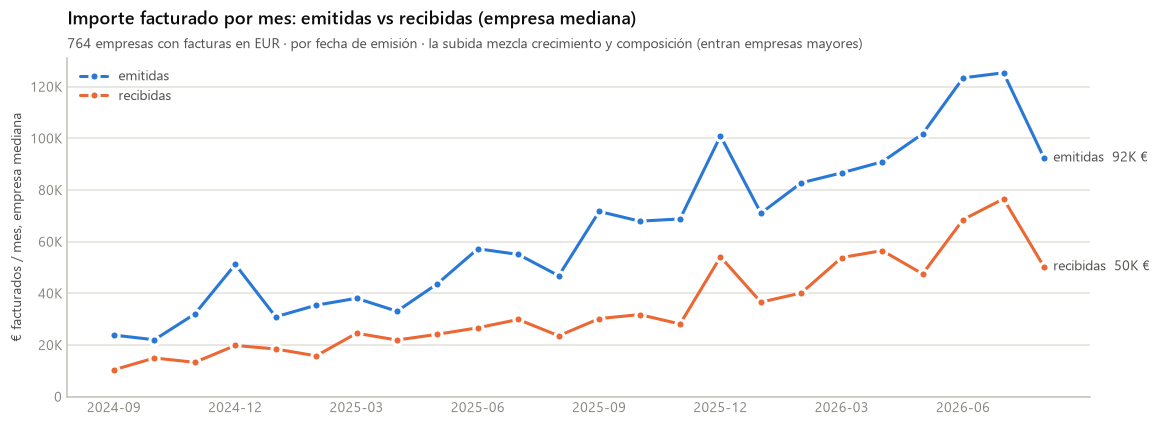

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
idx = month_ticks(ax, inv_m.index)
for i, c in enumerate(inv_m.columns):
    ax.plot(idx, inv_m[c].values, color=SERIES[i], label=c, **marker(markersize=6))
ax.set_ylim(0, None)
end_labels(ax, idx[-1], inv_m.iloc[-1].values, [f"{c}  {fmt_k(v)} €" for c, v in inv_m.iloc[-1].items()])
ax.yaxis.set_major_formatter(KFMT)
ax.set_ylabel("€ facturados / mes, empresa mediana")
ax.legend(loc="upper left")
title(ax, "Importe facturado por mes: emitidas vs recibidas (empresa mediana)",
      f"{inv_eur['company_id'].nunique():,} empresas con facturas en EUR · por fecha de emisión · la subida mezcla crecimiento y composición (entran empresas mayores)")
plt.show()

In [18]:
status = (inv.dropna(subset=["direction"])
             .assign(status=lambda d: d["status"].where(d["status"].isin(["paid", "overdue", "pending"]), "otros"))
             .pipe(lambda d: pd.crosstab(d["direction"], d["status"], normalize="index"))
             [["paid", "overdue", "pending", "otros"]]
             .rename(index={"issued": "emitidas", "received": "recibidas"}))
status

status,paid,overdue,pending,otros
direction,,,,
emitidas,0.68,0.27,0.03,0.01
recibidas,0.77,0.17,0.03,0.02


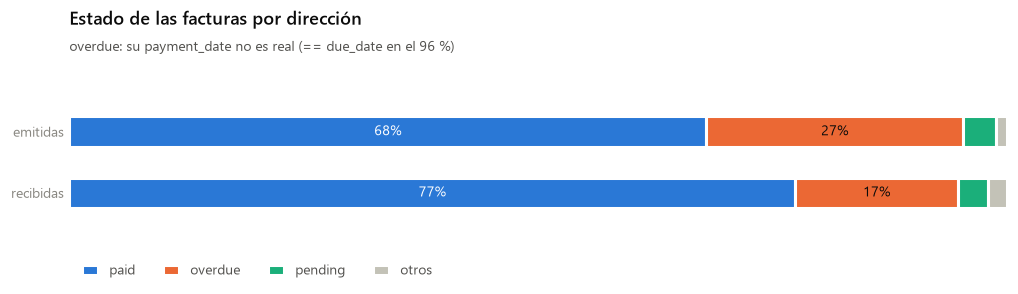

In [19]:
fig, ax = plt.subplots(figsize=(11, 2.6))
stacked_share(ax, status, colors=[SERIES[0], SERIES[1], SERIES[2], GRAY], legend_ncol=4)
title(ax, "Estado de las facturas por dirección", "overdue: su payment_date no es real (== due_date en el 96 %)")
plt.show()

In [20]:
paid = inv[(inv["status"] == "paid") & inv["direction"].notna()].dropna(subset=["due_date", "payment_date"])
delay_df = pd.DataFrame({
    "dias": (paid["payment_date"] - paid["due_date"]).dt.days,
    "direction": paid["direction"].map({"issued": "emitidas (cobro)", "received": "recibidas (pago)"}),
})
delay_stats = delay_df.groupby("direction")["dias"].describe(percentiles=[.25, .5, .75, .9]).round(1)
delay_stats["% exactamente 0"] = delay_df.groupby("direction")["dias"].apply(lambda s: round(100 * (s == 0).mean(), 1))
delay_stats["% > 0"] = delay_df.groupby("direction")["dias"].apply(lambda s: round(100 * (s > 0).mean(), 1))
delay_stats

,count,mean,std,min,25%,50%,75%,90%,max,% exactamente 0,% > 0
direction,,,,,,,,,,,
emitidas (cobro),"249,016.00",11.30,49.90,"-3,656.00",0.00,0.00,6.00,37.00,"2,010.00",49.00,35.70
recibidas (pago),"410,223.00",8.30,57.50,"-1,601.00",0.00,0.00,4.00,28.00,"9,263.00",53.80,32.60


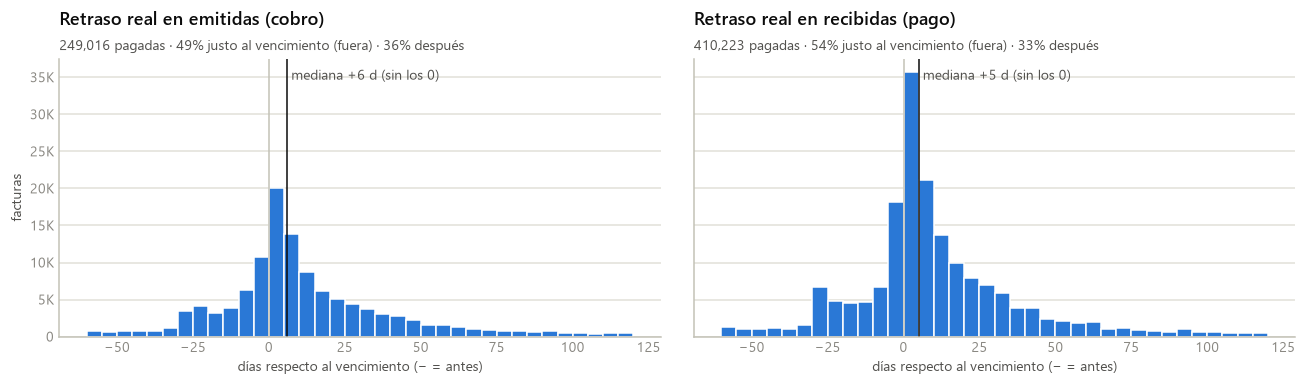

In [21]:
bins = np.arange(-60, 125, 5)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (name, g) in zip(axes, delay_df.groupby("direction")):
    late = g.loc[g["dias"] != 0, "dias"]                  # el pico en 0 (pagadas el día del vencimiento) se saca del histograma
    ax.hist(late[late.between(-60, 120)], bins=bins, color=SERIES[0], edgecolor=SURFACE, linewidth=1)
    ax.axvline(0, color=INK["axis"], linewidth=1)
    median_line(ax, late.median(), f"mediana {late.median():+.0f} d (sin los 0)")
    ax.yaxis.set_major_formatter(KFMT)
    ax.set_xlabel("días respecto al vencimiento (− = antes)")
    title(ax, f"Retraso real en {name}",
          f"{len(g):,} pagadas · {(g['dias'] == 0).mean():.0%} justo al vencimiento (fuera) · {(g['dias'] > 0).mean():.0%} después")
axes[0].set_ylabel("facturas")
fig.tight_layout(w_pad=2)
plt.show()

## 6. Deuda

378 empresas con algún producto de deuda; 87 préstamos (40 empresas) con cuadro de amortización y tipo de interés. La curva de tipos **no sale del dataset** (tipos 0–11 %, mediana 3 %): irá en la capa de alta fidelidad.

`granted` y `outstanding` vienen en **negativo** (saldo debido) → aquí en valor absoluto.

In [22]:
dtype = (debt.assign(outstanding_abs=debt["outstanding"].abs(), granted_abs=debt["granted"].abs())
             .groupby("type").agg(productos=("product_id", "size"), empresas=("company_id", "nunique"),
                                  pendiente_M=("outstanding_abs", lambda s: s.sum() / 1e6),
                                  concedido_M=("granted_abs", lambda s: s.sum() / 1e6))
             .sort_values("productos", ascending=False).round(1))
dtype

,productos,empresas,pendiente_M,concedido_M
type,,,,
loan,1022,239,"1,376.50","1,817.00"
lineofcredit,536,206,309.00,499.20
confirming,229,70,54.30,277.90
leasing,179,45,59.90,183.80
guarantee,155,51,88.20,99.50
mortgage,60,11,8.30,18.90
renting,34,14,0.30,0.60
factoring,24,19,12.50,37.80


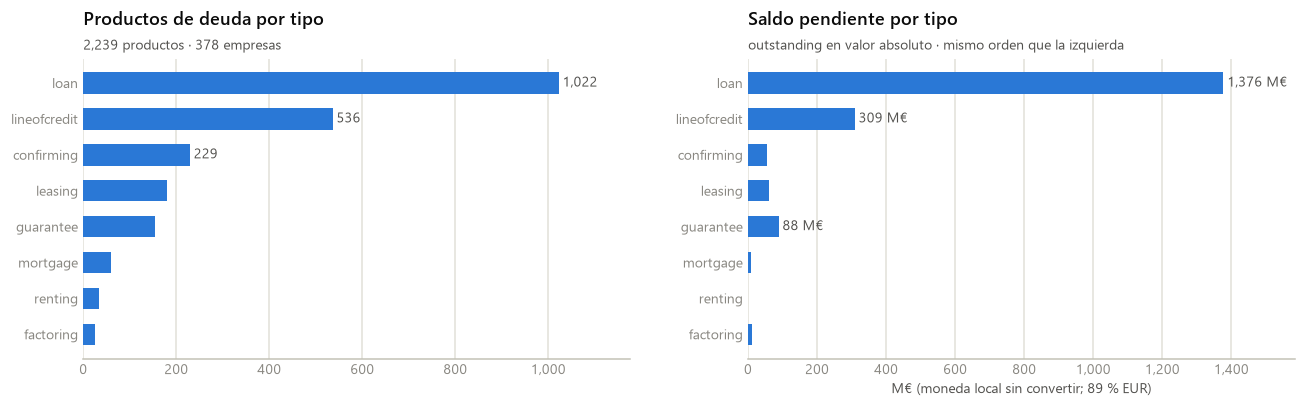

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
hbars(axes[0], dtype.index.tolist(), dtype["productos"].values, label_top=3, xfmt=PLAIN)
title(axes[0], "Productos de deuda por tipo", f"{len(debt):,} productos · {debt['company_id'].nunique()} empresas")
hbars(axes[1], dtype.index.tolist(), dtype["pendiente_M"].values, label_top=3, fmt=lambda v: f"{v:,.0f} M€", xfmt=PLAIN)
axes[1].set_xlabel("M€ (moneda local sin convertir; 89 % EUR)")
title(axes[1], "Saldo pendiente por tipo", "outstanding en valor absoluto · mismo orden que la izquierda")
fig.tight_layout(w_pad=3)
plt.show()

In [24]:
loc = debt[(debt["type"] == "lineofcredit") & debt["granted"].notna() & debt["liquidity"].notna() & (debt["granted"] != 0)]
usage = ((loc["granted"].abs() - loc["liquidity"]) / loc["granted"].abs()).clip(0, 1).rename("uso")
rates = dsc["annual_interest_rate_or_spread"].dropna()
pd.DataFrame({"uso de líneas de crédito": usage.describe(), "tipo de interés (87 préstamos)": rates.describe()}).round(3)

,uso de líneas de crédito,tipo de interés (87 préstamos)
count,425.00,87.00
mean,0.34,0.03
std,0.40,0.02
min,0.00,0.00
25%,0.00,0.02
50%,0.04,0.03
75%,0.78,0.04
max,1.00,0.11


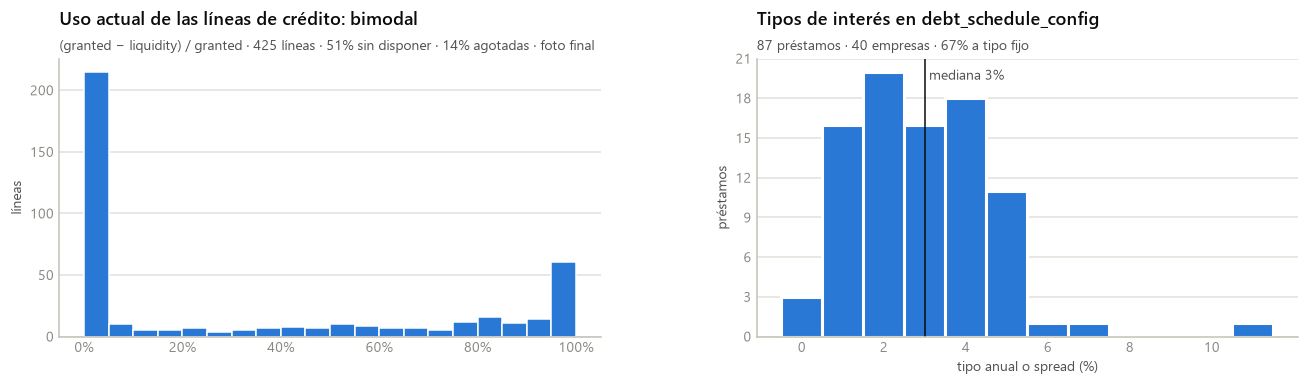

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

ax = axes[0]
ax.hist(usage, bins=np.linspace(0, 1, 21), color=SERIES[0], edgecolor=SURFACE, linewidth=1)
ax.xaxis.set_major_formatter(PCT)
ax.set_ylabel("líneas")
title(ax, "Uso actual de las líneas de crédito: bimodal",
      f"(granted − liquidity) / granted · {len(usage)} líneas · {(usage < 0.05).mean():.0%} sin disponer · {(usage > 0.95).mean():.0%} agotadas · foto final")

ax = axes[1]
ax.hist(rates * 100, bins=np.arange(-0.5, 12.5, 1), color=SERIES[0], edgecolor=SURFACE, linewidth=2)
median_line(ax, rates.median() * 100, f"mediana {rates.median():.0%}")
ax.set_xticks(range(0, 12, 2))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("tipo anual o spread (%)")
ax.set_ylabel("préstamos")
title(ax, "Tipos de interés en debt_schedule_config",
      f"{len(rates)} préstamos · {dsc['company_id'].nunique()} empresas · {(dsc['interest_type']=='fixed').mean():.0%} a tipo fijo")
fig.tight_layout(w_pad=3)
plt.show()

## 7. Bancos y saldos finales

`balances.csv` es **solo la foto del 1-sep-2026**. Para tener saldo mensual hay que reconstruirlo hacia atrás con las transacciones (§8). Aquí: qué bancos aparecen y cómo se reparte el saldo final de las cuentas corrientes.

In [26]:
banks = bank["bank_name"].value_counts()
banks_top = pd.concat([banks.iloc[:10], pd.Series({f"Otros ({banks.iloc[10:].size} bancos)": banks.iloc[10:].sum()})])
chk = bal.merge(bank.loc[bank["type"] == "checking", ["product_id"]], on="product_id")
chk_bal = chk["balance"].dropna()
print(f"cuentas corrientes con saldo: {len(chk_bal):,} · a 0 €: {(chk_bal == 0).mean():.0%} · "
      f"en negativo: {(chk_bal < 0).mean():.1%} · mediana {chk_bal.median():,.0f} €")
banks_top.to_frame("productos").T

cuentas corrientes con saldo: 4,647 · a 0 €: 20% · en negativo: 2.0% · mediana 6,782 €


,Banco Santander Empresas,Caixabank Empresas,BBVA Net Cash Empresas,Other (customer-defined),Banco Sabadell Empresas,Caixabank,Bankinter Empresas,Banco Santander,Banca March,Banco Sabadell T. sec - CAL Empresas,Otros (190 bancos)
productos,824,758,413,347,346,293,263,250,186,170,2137


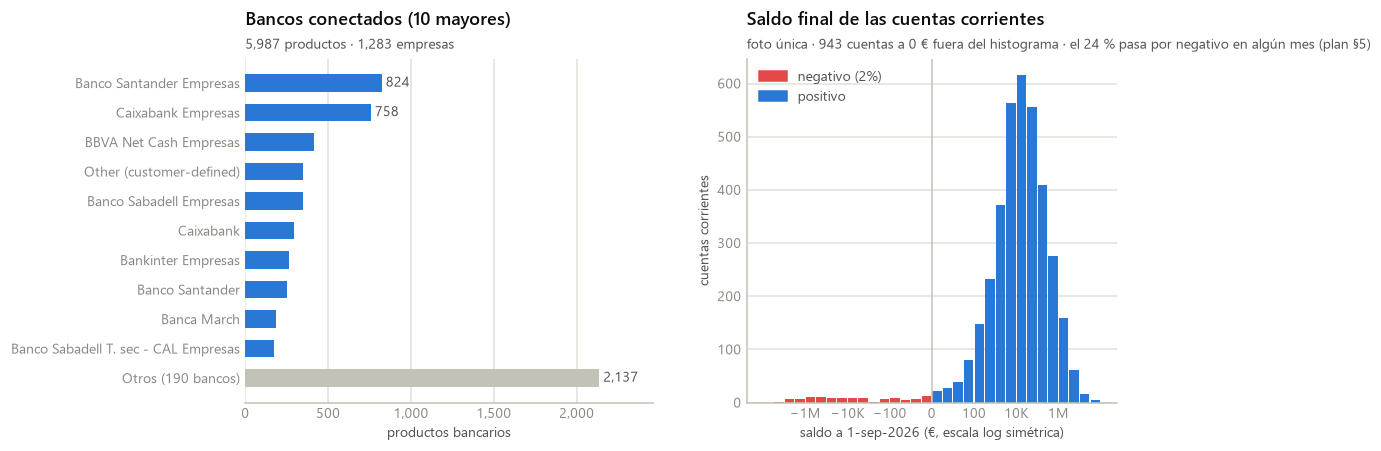

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
hbars(ax, banks_top.index.tolist(), banks_top.values, color=[SERIES[0]] * 10 + [GRAY], label_top=3, xfmt=PLAIN)
ax.set_xlabel("productos bancarios")
title(ax, "Bancos conectados (10 mayores)", f"{len(bank):,} productos · {bank['company_id'].nunique():,} empresas")

ax = axes[1]
nonzero = chk_bal[chk_bal != 0]
slog = np.sign(nonzero) * np.log10(nonzero.abs())
counts, edges = np.histogram(slog, bins=np.arange(-8, 8.5, 0.5))
centers = (edges[:-1] + edges[1:]) / 2
ax.bar(centers, counts, width=0.45, color=[DIV["neg"] if c < 0 else DIV["pos"] for c in centers])
ax.axvline(0, color=INK["axis"], linewidth=1)
ax.set_xticks([-6, -4, -2, 0, 2, 4, 6], ["−1M", "−10K", "−100", "0", "100", "10K", "1M"])
ax.set_xlabel("saldo a 1-sep-2026 (€, escala log simétrica)")
ax.set_ylabel("cuentas corrientes")
ax.legend(handles=[mpl.patches.Patch(color=DIV["neg"], label=f"negativo ({(chk_bal < 0).mean():.0%})"),
                   mpl.patches.Patch(color=DIV["pos"], label="positivo")], loc="upper left")
title(ax, "Saldo final de las cuentas corrientes",
      f"foto única · {(chk_bal == 0).sum():,} cuentas a 0 € fuera del histograma · el 24 % pasa por negativo en algún mes (plan §5)")
fig.tight_layout(w_pad=3)
plt.show()

## 8. Ficha de una empresa: trayectoria, no foto

Lo que verá el asesor: flujos mensuales, saldo reconstruido y facturación de **una** empresa. Cambia `COMPANY` para explorar otra.

Saldo reconstruido: `saldo_fin(m) = saldo_final − Σ movimientos posteriores a m`, por cuenta corriente con saldo en `balances.csv`. Esto lo hará `xray.features`; aquí es solo un preview.

Candidatas: EUR, 24 meses completos, con deuda y facturas, y entradas medianas entre 50 K y 5 M €/mes (fuera los barridos de tesorería de §4). Ordenadas por número de productos de deuda: son el pool de la demo de refinanciación.

In [28]:
cands = (pd.DataFrame({"meses": n_months})
           .join(cm["entradas"].groupby("company_id").median().rename("entradas_mediana"), how="inner")
           .join(debt.groupby("company_id").size().rename("productos_deuda"), how="inner")
           .join(inv.groupby("company_id").size().rename("facturas"), how="inner")
           .join(chk.groupby("company_id")["balance"].sum().rename("saldo_final"), how="inner")
           .query("meses >= 24 and facturas >= 500 and 50e3 <= entradas_mediana <= 5e6")
           .sort_values(["productos_deuda", "facturas"], ascending=False))
COMPANY = cands.index[0]
print(f"{len(cands)} candidatas · COMPANY = {COMPANY}")
cands.head(8)

51 candidatas · COMPANY = COMP_0803


,meses,entradas_mediana,productos_deuda,facturas,saldo_final
company_id,,,,,
COMP_0803,25,"3,526,382.76",35,2819,"1,131,737.89"
COMP_0686,25,"815,920.29",26,3768,"-151,278.58"
COMP_0471,25,"2,991,521.49",25,3837,"859,908.78"
COMP_0491,25,"837,830.69",16,1044,"121,010.20"
COMP_0180,25,"772,062.15",15,2851,"92,609.91"
COMP_0101,24,"526,921.87",11,2607,"47,605.05"
COMP_0169,25,"691,625.20",10,3602,"217,665.33"
COMP_0743,25,"453,294.04",10,2207,"1,049,607.58"


In [29]:
def monthly_flows(company):
    d = tx[tx["company_id"] == company]
    f = (d.assign(entradas=d["amount"].clip(lower=0), salidas=d["amount"].clip(upper=0))
           .groupby("month")[["entradas", "salidas"]].sum().reindex(FULL_MONTHS).fillna(0))
    f["neto"] = f["entradas"] + f["salidas"]
    return f


def reconstructed_balance(company):
    # saldo agregado de las cuentas corrientes de `company` al cierre de cada mes
    prods = chk.loc[chk["company_id"] == company, ["product_id", "balance"]].dropna()
    d = tx[tx["product_id"].isin(prods["product_id"])]
    monthly = (d.groupby(["product_id", "month"])["amount"].sum().unstack()
                 .reindex(index=prods["product_id"], columns=FULL_MONTHS).fillna(0))
    after = monthly.iloc[:, ::-1].cumsum(axis=1).iloc[:, ::-1] - monthly     # Σ movimientos posteriores a m
    end_of_month = prods["balance"].values[:, None] - after.values
    return pd.Series(end_of_month.sum(axis=0), index=FULL_MONTHS, name="saldo")


def company_invoices(company):
    d = inv[(inv["company_id"] == company) & inv["direction"].notna()]
    return (d.assign(month=d["issuance_date"].dt.to_period("M"), a=d["amount"].abs())
              .groupby(["month", "direction"])["a"].sum().unstack()
              .reindex(index=FULL_MONTHS, columns=["issued", "received"]).fillna(0)
              .rename(columns={"issued": "emitidas", "received": "recibidas"}))


f_c, b_c, i_c = monthly_flows(COMPANY), reconstructed_balance(COMPANY), company_invoices(COMPANY)
pd.concat([f_c, b_c, i_c], axis=1).tail(6)

,entradas,salidas,neto,saldo,emitidas,recibidas
2026-03,"2,820,107.03","-4,398,048.99","-1,577,941.96","1,446,259.85","552,392.91","316,673.08"
2026-04,"2,195,601.11","-3,123,004.86","-927,403.75","630,129.58","376,842.43","352,254.00"
2026-05,"3,833,560.03","-3,277,869.88","555,690.15","998,400.41","1,876,258.09","302,307.69"
2026-06,"2,843,480.42","-3,265,828.40","-422,347.98","583,848.30","565,732.51","457,910.99"
2026-07,"2,441,058.83","-2,080,122.40","360,936.43","1,154,312.90","1,706,318.66","310,324.37"
2026-08,"2,950,302.95","-2,793,924.68","156,378.27","1,131,737.89","292,646.12","298,962.38"


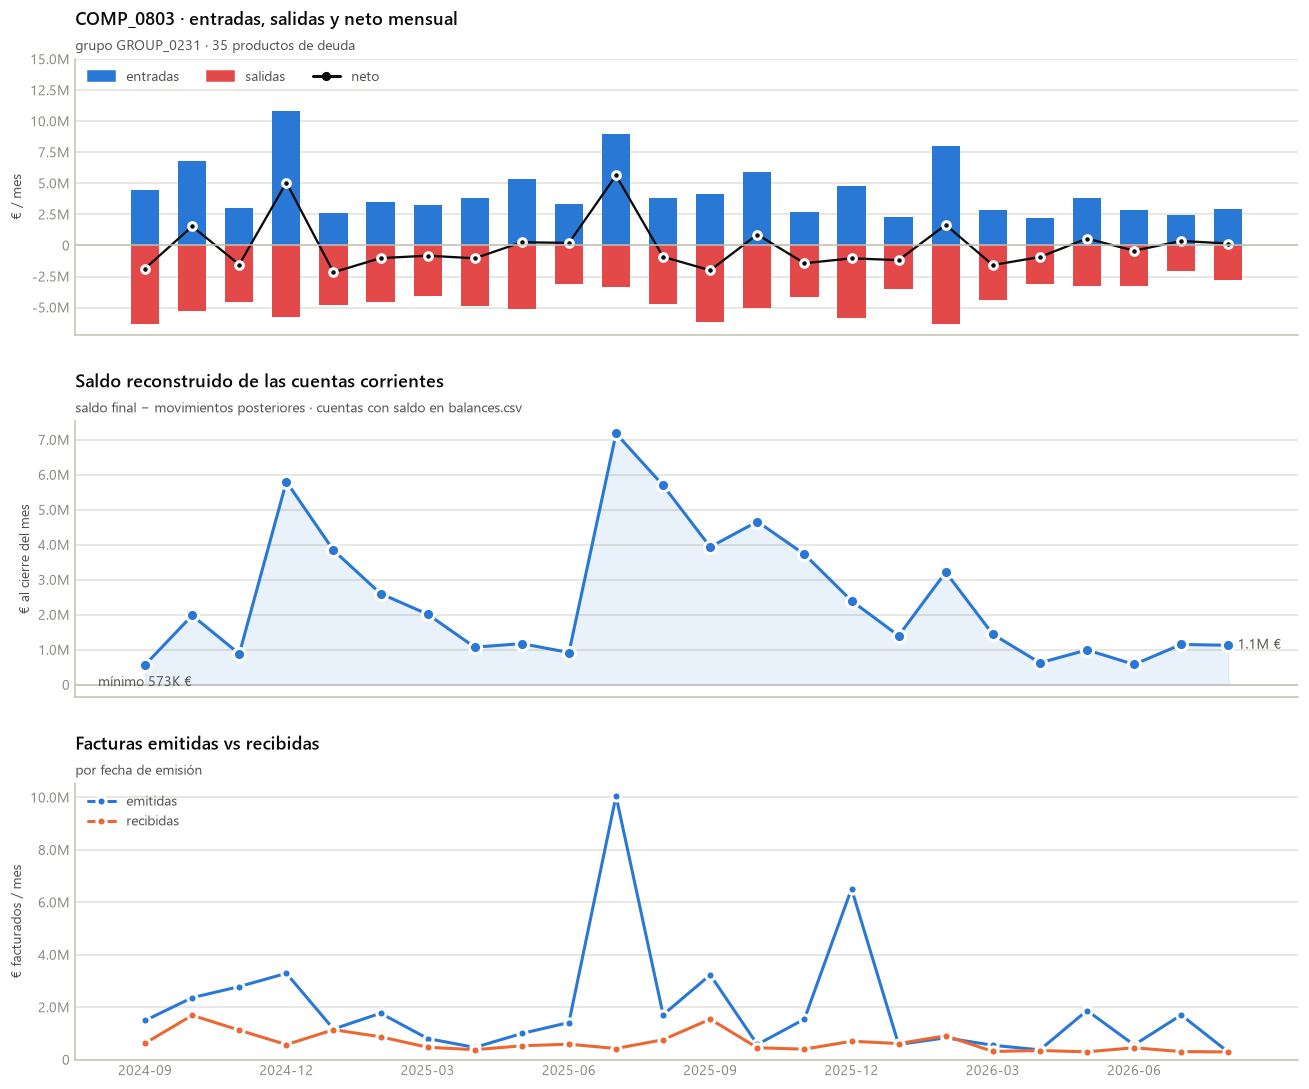

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax = axes[0]
idx = flows_chart(ax, f_c)
ax.set_ylabel("€ / mes")
title(ax, f"{COMPANY} · entradas, salidas y neto mensual",
      f"grupo {companies.set_index('company_id').loc[COMPANY, 'group_id']} · {int(cands.loc[COMPANY, 'productos_deuda'])} productos de deuda")

ax = axes[1]
balance_line(ax, idx, b_c.values)
i_min = int(np.argmin(b_c.values))
ax.annotate(f"mínimo {fmt_k(b_c.min())} €", (idx[i_min], b_c.min()), xytext=(0, -14),
            textcoords="offset points", ha="center", fontsize=9, color=INK["secondary"])
end_label(ax, idx[-1], b_c.iloc[-1], f"{fmt_k(b_c.iloc[-1])} €")
ax.yaxis.set_major_formatter(KFMT)
ax.set_ylabel("€ al cierre del mes")
title(ax, "Saldo reconstruido de las cuentas corrientes", "saldo final − movimientos posteriores · cuentas con saldo en balances.csv")

ax = axes[2]
for i, c in enumerate(i_c.columns):
    ax.plot(idx, i_c[c].values, color=SERIES[i], label=c, **marker(markersize=6))
ax.set_ylim(0, None)
end_labels(ax, idx[-1], i_c.iloc[-1].values, list(i_c.columns))
ax.yaxis.set_major_formatter(KFMT)
ax.set_ylabel("€ facturados / mes")
ax.legend(loc="upper left")
title(ax, "Facturas emitidas vs recibidas", "por fecha de emisión")
fig.tight_layout(h_pad=2.5)
plt.show()

Seis empresas más, misma medida (saldo reconstruido) en **pequeños múltiplos**: cada panel con su propia escala, un solo hue. Aquí es donde se ve "bache o caída".

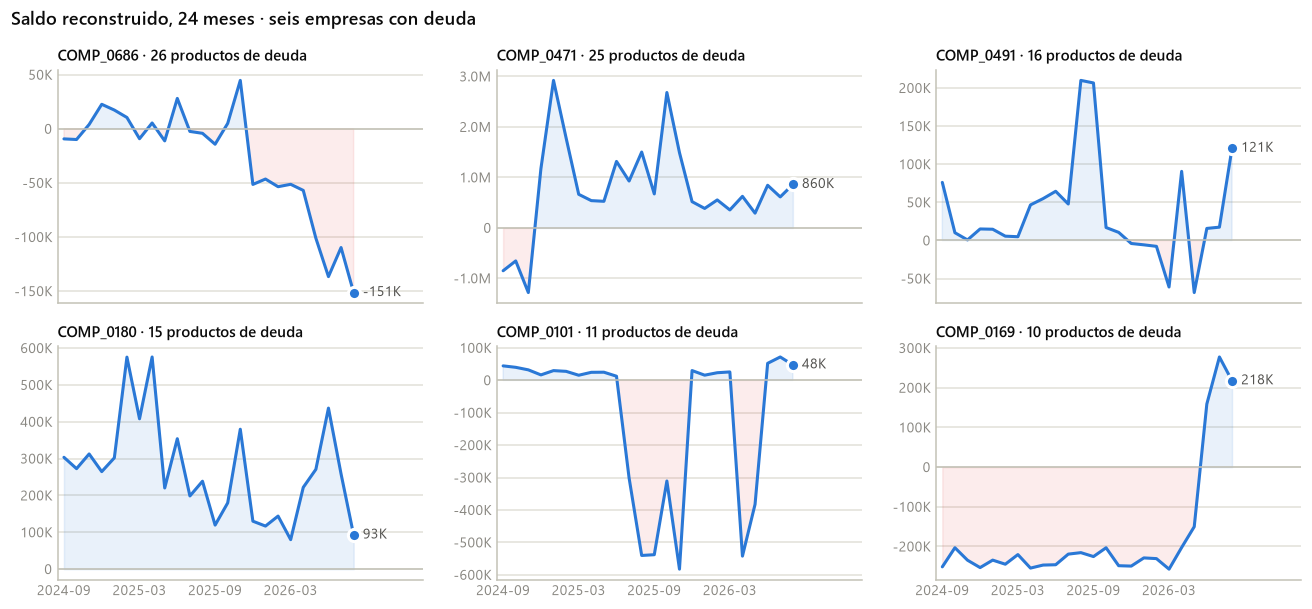

In [31]:
sample = cands.index[1:7]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.6), sharex=True)
for ax, c in zip(axes.ravel(), sample):
    b = reconstructed_balance(c)
    x = np.arange(len(b))
    balance_line(ax, x, b.values, ms=0)
    ax.plot(x[-1], b.iloc[-1], color=SERIES[0], **marker())
    end_label(ax, x[-1], b.iloc[-1], fmt_k(b.iloc[-1]))
    ax.yaxis.set_major_formatter(KFMT)
    ax.set_xlim(-0.5, len(b) + 4.5)
    month_ticks(ax, FULL_MONTHS, every=6)
    ax.set_title(f"{c} · {int(cands.loc[c, 'productos_deuda'])} productos de deuda", fontsize=10, pad=6)
fig.suptitle("Saldo reconstruido, 24 meses · seis empresas con deuda", x=0.01, ha="left", fontsize=11.5, fontweight="semibold")
fig.tight_layout(w_pad=2, h_pad=1.5)
plt.show()

## 9. Señales · antes de nada, validar la reconstrucción de saldo

Las secciones 9–15 pasan de *qué hay en las tablas* a *las señales del índice de estado* (plan §2): saldo mínimo, vencidas a proveedores, servicio de deuda, entradas vs año anterior; más uso de línea y concentración de clientes. Todo es **preview** de lo que harán `xray.features` y `xray.labels`: aquí se agrega y se pinta.

Primero, una comprobación. Reconstruir el saldo hacia atrás desde una única foto acumula cualquier movimiento que falte. Si la proporción de cuentas en negativo cambia sistemáticamente con la distancia a la foto, la señal (i) del índice está contaminada. Tres series: todas las cuentas activas cada mes, una **cohorte fija** (activas desde 2024-09, sin efecto composición) y esa cohorte reconstruida **solo con movimientos `booked`** (sin pendientes).

In [32]:
chk_b = chk.dropna(subset=["balance"]).drop_duplicates("product_id")
chk_company = chk_b.set_index("product_id")["company_id"]


def eom_balances(transactions):
    # saldo al cierre de mes de todas las cuentas corrientes con saldo en balances.csv: matriz cuenta × mes
    d = transactions[transactions["product_id"].isin(chk_b["product_id"])]
    monthly = (d.groupby(["product_id", "month"])["amount"].sum().unstack()
                 .reindex(index=chk_b["product_id"], columns=FULL_MONTHS).fillna(0))
    after = monthly.iloc[:, ::-1].cumsum(axis=1).iloc[:, ::-1] - monthly       # Σ movimientos posteriores a m
    eom = pd.DataFrame(chk_b["balance"].values[:, None] - after.values, index=chk_b["product_id"], columns=FULL_MONTHS)
    active = monthly.ne(0).cummax(axis=1)                                         # desde el primer mes con movimientos
    return eom, active


eom_all, active_all = eom_balances(tx)
eom_booked, _ = eom_balances(tx[tx["status"] == "booked"])
cohort = active_all.iloc[:, 0]                                                    # activas desde 2024-09

neg_share = pd.DataFrame({
    "todas las cuentas activas": (eom_all.lt(0) & active_all).sum() / active_all.sum(),
    "cohorte fija (desde 2024-09)": eom_all[cohort].lt(0).mean(),
    "cohorte fija, solo booked": eom_booked[cohort].lt(0).mean(),
})
first_idx = active_all.values.argmax(axis=1)
start_bal = pd.Series(eom_all.values[np.arange(len(eom_all)), first_idx], index=eom_all.index)
print(f"{len(eom_all):,} cuentas corrientes · {int(cohort.sum())} en la cohorte fija · "
      f"{(start_bal < -1e5).sum()} arrancan su historia por debajo de −100 K")
neg_share.T.round(3)

4,647 cuentas corrientes · 882 en la cohorte fija · 120 arrancan su historia por debajo de −100 K


,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08
todas las cuentas activas,0.10,0.10,0.09,0.10,0.09,0.07,0.08,0.07,0.08,0.08,0.07,0.07,0.07,0.07,0.07,0.07,0.07,0.06,0.07,0.07,0.06,0.05,0.04,0.02
cohorte fija (desde 2024-09),0.10,0.10,0.09,0.10,0.09,0.10,0.10,0.08,0.08,0.09,0.08,0.08,0.07,0.08,0.08,0.07,0.07,0.06,0.07,0.06,0.06,0.05,0.04,0.02
"cohorte fija, solo booked",0.11,0.10,0.09,0.10,0.09,0.10,0.10,0.08,0.09,0.09,0.08,0.08,0.07,0.08,0.08,0.07,0.07,0.06,0.07,0.06,0.06,0.05,0.04,0.02


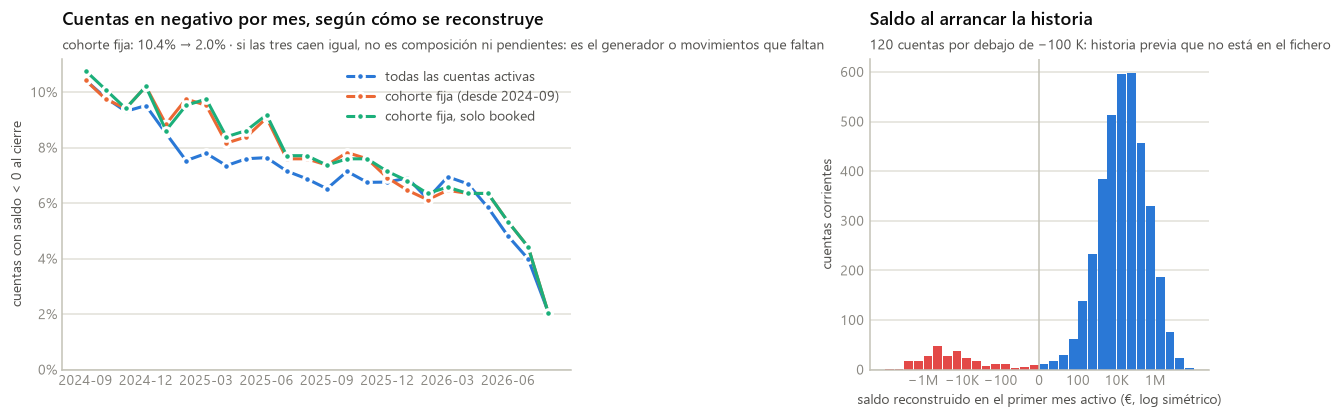

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
idx = month_ticks(ax, neg_share.index)
for i, c in enumerate(neg_share.columns):
    ax.plot(idx, neg_share[c].values, color=SERIES[i], label=c, **marker(markersize=5))
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, None)
ax.set_ylabel("cuentas con saldo < 0 al cierre")
ax.legend(loc="upper right")
first, last = neg_share.iloc[0, 1], neg_share.iloc[-1, 1]
title(ax, "Cuentas en negativo por mes, según cómo se reconstruye",
      f"cohorte fija: {first:.1%} → {last:.1%} · si las tres caen igual, no es composición ni pendientes: es el generador o movimientos que faltan")

ax = axes[1]
nonzero = start_bal[start_bal != 0]
slog = np.sign(nonzero) * np.log10(nonzero.abs())
counts, edges = np.histogram(slog, bins=np.arange(-8, 8.5, 0.5))
centers = (edges[:-1] + edges[1:]) / 2
ax.bar(centers, counts, width=0.45, color=[DIV["neg"] if c < 0 else DIV["pos"] for c in centers])
ax.axvline(0, color=INK["axis"], linewidth=1)
ax.set_xticks([-6, -4, -2, 0, 2, 4, 6], ["−1M", "−10K", "−100", "0", "100", "10K", "1M"])
ax.set_xlabel("saldo reconstruido en el primer mes activo (€, log simétrico)")
ax.set_ylabel("cuentas corrientes")
title(ax, "Saldo al arrancar la historia",
      f"{(start_bal < -1e5).sum()} cuentas por debajo de −100 K: historia previa que no está en el fichero")
fig.tight_layout(w_pad=3)
plt.show()

## 10. Uso de la línea de crédito en el tiempo

La señal con más evidencia (investigación §7): el uso de la línea sube meses antes del estrés. §6 solo tenía la foto final. En las líneas con saldo en `balances.csv`, **dispuesto = −saldo** (coincide con `granted − liquidity` en el 98 %), así que el dispuesto mensual se reconstruye hacia atrás igual que el saldo corriente. Uso de la empresa = Σ dispuesto / Σ concedido de sus líneas activas ese mes, recortado a [0, 1].

In [34]:
loc_b = (debt.loc[debt["type"] == "lineofcredit", ["product_id", "company_id", "granted"]]
             .dropna().query("granted != 0")
             .merge(bal[["product_id", "balance"]].dropna(), on="product_id").drop_duplicates("product_id"))
loc_b["granted_abs"] = loc_b["granted"].abs()

d = tx[tx["product_id"].isin(loc_b["product_id"])]
lm = (d.groupby(["product_id", "month"])["amount"].sum().unstack()
        .reindex(index=loc_b["product_id"], columns=FULL_MONTHS).fillna(0))
after = lm.iloc[:, ::-1].cumsum(axis=1).iloc[:, ::-1] - lm
drawn = pd.DataFrame(-(loc_b["balance"].values[:, None] - after.values), index=loc_b["product_id"], columns=FULL_MONTHS)
drawn = drawn.where(lm.ne(0).cummax(axis=1))                       # solo desde el primer movimiento de la línea
has_tx = lm.ne(0).any(axis=1)
drawn = drawn[has_tx]
gr = loc_b.set_index("product_id").loc[drawn.index]
gmat = pd.DataFrame(np.where(drawn.notna(), gr["granted_abs"].values[:, None], np.nan), index=drawn.index, columns=FULL_MONTHS)
usage = (drawn.groupby(gr["company_id"].values).sum(min_count=1)
         / gmat.groupby(gr["company_id"].values).sum(min_count=1)).clip(0, 1)

usage_q = usage.quantile([.25, .5, .75]).T.set_axis(["p25", "p50", "p75"], axis=1)
usage_q["empresas"] = usage.notna().sum()
d6 = (usage.iloc[:, -1] - usage.iloc[:, -7]).dropna()             # Δ uso en los últimos 6 meses
print(f"{len(drawn)} líneas con saldo, límite y movimientos · {usage.shape[0]} empresas · "
      f"Δ6m: sube > 10 pp en {(d6 > 0.10).mean():.0%}, baja > 10 pp en {(d6 < -0.10).mean():.0%}")
usage_q.T.round(2)

286 líneas con saldo, límite y movimientos · 137 empresas · Δ6m: sube > 10 pp en 18%, baja > 10 pp en 28%


,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08
p25,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
p50,0.21,0.36,0.45,0.51,0.31,0.42,0.45,0.59,0.44,0.44,0.49,0.27,0.28,0.45,0.30,0.29,0.32,0.42,0.35,0.29,0.27,0.26,0.10,0.19
p75,0.77,1.00,1.00,0.99,0.88,0.92,0.96,0.94,0.92,0.91,0.96,0.93,0.92,0.91,0.94,0.84,0.90,0.89,0.89,0.90,0.87,0.79,0.69,0.67
empresas,29.00,35.00,37.00,42.00,57.00,60.00,63.00,66.00,69.00,71.00,76.00,78.00,80.00,87.00,89.00,94.00,114.00,120.00,128.00,128.00,130.00,135.00,137.00,137.00


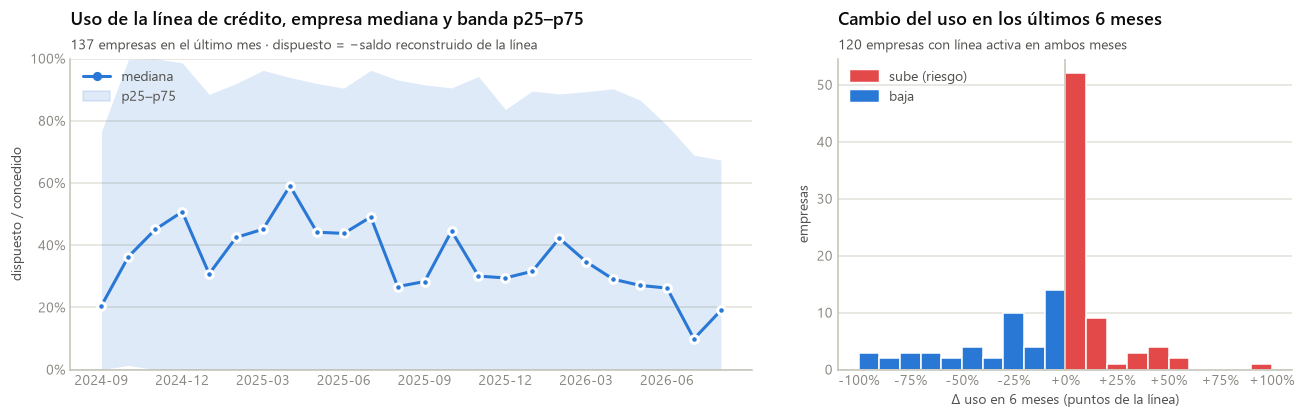

In [35]:
def quantile_band(ax, x, q, color=SERIES[0], label="mediana"):
    # mediana en línea + banda p25–p75 lavada al 15 %: una sola serie, un solo hue
    ax.fill_between(x, q["p25"].values, q["p75"].values, color=color, alpha=0.15, linewidth=0)
    ax.plot(x, q["p50"].values, color=color, label=label, **marker(markersize=5))
    ax.legend(handles=[mpl.lines.Line2D([], [], color=color, marker="o", markersize=5, label=label),
                       mpl.patches.Patch(color=color, alpha=0.15, label="p25–p75")], loc="upper left")


fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
idx = month_ticks(ax, usage_q.index)
quantile_band(ax, idx, usage_q)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 1)
ax.set_ylabel("dispuesto / concedido")
title(ax, "Uso de la línea de crédito, empresa mediana y banda p25–p75",
      f"{usage_q['empresas'].iloc[-1]} empresas en el último mes · dispuesto = −saldo reconstruido de la línea")

ax = axes[1]
bins = np.arange(-1, 1.05, 0.1)
ax.hist(d6[d6 < 0], bins=bins, color=DIV["pos"], edgecolor=SURFACE, linewidth=1)
ax.hist(d6[d6 >= 0], bins=bins, color=DIV["neg"], edgecolor=SURFACE, linewidth=1)
ax.axvline(0, color=INK["axis"], linewidth=1)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:+.0%}"))
ax.set_xlabel("Δ uso en 6 meses (puntos de la línea)")
ax.set_ylabel("empresas")
ax.legend(handles=[mpl.patches.Patch(color=DIV["neg"], label="sube (riesgo)"), mpl.patches.Patch(color=DIV["pos"], label="baja")], loc="upper left")
title(ax, "Cambio del uso en los últimos 6 meses", f"{len(d6)} empresas con línea activa en ambos meses")
fig.tight_layout(w_pad=3)
plt.show()

Las seis empresas cuyo uso **más ha subido** en 6 meses, en pequeños múltiplos: es el patrón de Jiménez/López/Saurina si existe en el dataset (subida sostenida, no un escalón por una disposición puntual).

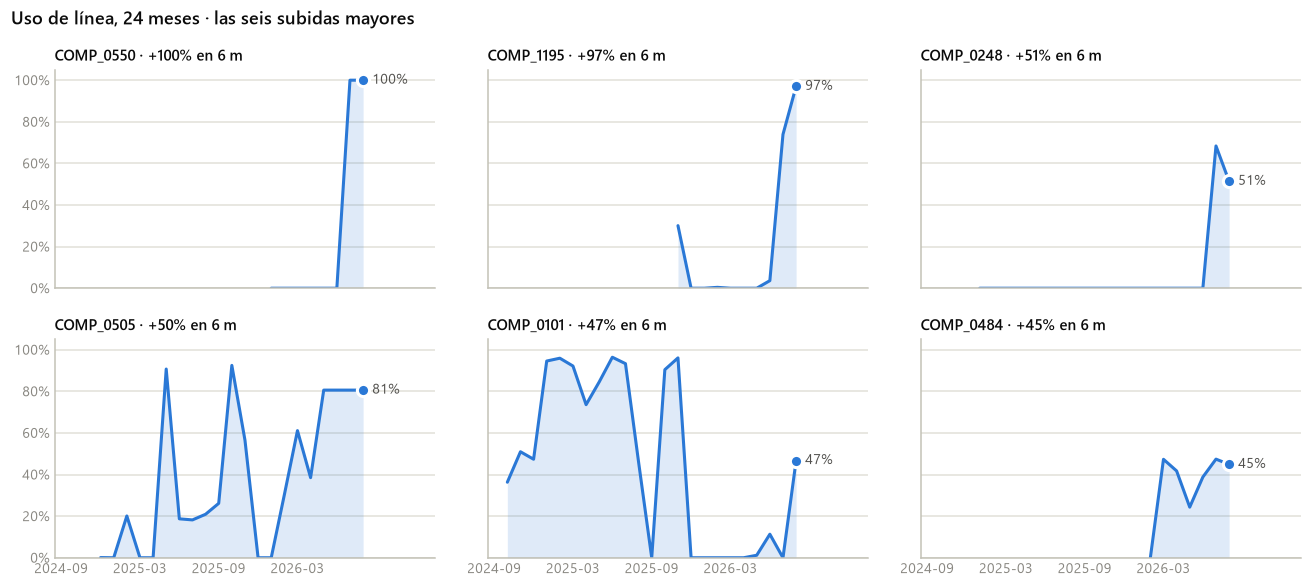

In [36]:
rising = d6.sort_values(ascending=False).index[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.4), sharex=True, sharey=True)
for ax, c in zip(axes.ravel(), rising):
    u = usage.loc[c]
    x = np.arange(len(u))
    ax.fill_between(x, u.values, 0, color=SERIES[0], alpha=0.15, linewidth=0)
    ax.plot(x, u.values, color=SERIES[0])
    ax.plot(x[-1], u.iloc[-1], color=SERIES[0], **marker())
    end_label(ax, x[-1], u.iloc[-1], f"{u.iloc[-1]:.0%}")
    ax.yaxis.set_major_formatter(PCT)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, len(u) + 4.5)
    month_ticks(ax, FULL_MONTHS, every=6)
    ax.set_title(f"{c} · {d6[c]:+.0%} en 6 m", fontsize=10, pad=6)
fig.suptitle("Uso de línea, 24 meses · las seis subidas mayores", x=0.01, ha="left", fontsize=11.5, fontweight="semibold")
fig.tight_layout(w_pad=2, h_pad=1.5)
plt.show()

## 11. Retraso a proveedores: stock de vencidas por mes

La métrica que usa el plan (§2, señal ii): **importe recibido vencido y no pagado / importe recibido en los últimos 3 meses**. Se reconstruye mes a mes con `due_date` y, en las pagadas, `payment_date`: una factura cuenta como vencida desde su mes de vencimiento hasta el mes en que se paga; en las no pagadas (`overdue`, `pending`), `payment_date` no es real y se consideran vivas hasta el final. Es un ratio por empresa, así que la moneda no importa.

In [37]:
rec = inv[(inv["direction"] == "received") & inv["due_date"].notna()].copy()
rec["a"] = rec["amount"].abs()
rec["due_m"] = rec["due_date"].dt.to_period("M")
paid_ok = rec["status"].eq("paid") & rec["payment_date"].notna()
rec["rel_m"] = pd.concat([rec["due_m"], rec["payment_date"].dt.to_period("M")], axis=1).max(axis=1).where(paid_ok)
rec["iss_m"] = rec["issuance_date"].dt.to_period("M")


def cum_by_month(frame, col):
    # importe acumulado por empresa hasta cada mes de FULL_MONTHS (incluye eventos anteriores a la ventana)
    ev = frame.dropna(subset=[col]).groupby(["company_id", col])["a"].sum().unstack()
    rng = pd.period_range(min(ev.columns.min(), FULL_MONTHS[0]), max(ev.columns.max(), FULL_MONTHS[-1]), freq="M")
    return ev.reindex(columns=rng).fillna(0).cumsum(axis=1)[FULL_MONTHS]


due_c, rel_c = cum_by_month(rec, "due_m"), cum_by_month(rec, "rel_m")
overdue_stock = (due_c - rel_c.reindex(due_c.index).fillna(0)).clip(lower=0)
received_3m = (rec.groupby(["company_id", "iss_m"])["a"].sum().unstack().reindex(columns=FULL_MONTHS).fillna(0)
                  .T.rolling(3, min_periods=1).sum().T)
overdue_ratio = (overdue_stock / received_3m.reindex(overdue_stock.index)).replace([np.inf, -np.inf], np.nan)
overdue_ratio = overdue_ratio.where(received_3m.reindex(overdue_stock.index) > 0)

ov_q = overdue_ratio.quantile([.25, .5, .75]).T.set_axis(["p25", "p50", "p75"], axis=1)
ov_q["empresas"] = overdue_ratio.notna().sum()
ov_last = overdue_ratio.iloc[:, -1].dropna()
print(f"{len(rec):,} facturas recibidas · {overdue_ratio.shape[0]} empresas · último mes: "
      f"{(ov_last == 0).mean():.0%} sin vencidas, {(ov_last > 1).mean():.0%} con vencidas > 3 meses de compras")
ov_q.T.round(2)

529,934 facturas recibidas · 783 empresas · último mes: 2% sin vencidas, 44% con vencidas > 3 meses de compras


,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08
p25,0.00,0.00,0.01,0.02,0.02,0.03,0.05,0.05,0.07,0.06,0.05,0.08,0.09,0.07,0.07,0.07,0.07,0.06,0.09,0.11,0.13,0.19,0.22,0.28
p50,0.04,0.10,0.13,0.23,0.31,0.31,0.44,0.53,0.57,0.54,0.48,0.54,0.61,0.55,0.50,0.50,0.45,0.48,0.50,0.53,0.52,0.67,0.71,0.84
p75,0.56,0.62,0.61,0.83,0.88,0.99,1.02,1.13,1.32,1.31,1.50,1.71,1.80,1.90,1.78,1.53,1.27,1.39,1.55,1.70,1.74,2.08,2.33,2.76
empresas,366.00,425.00,466.00,489.00,516.00,530.00,535.00,550.00,566.00,591.00,608.00,610.00,624.00,628.00,641.00,669.00,692.00,690.00,694.00,700.00,704.00,707.00,701.00,695.00


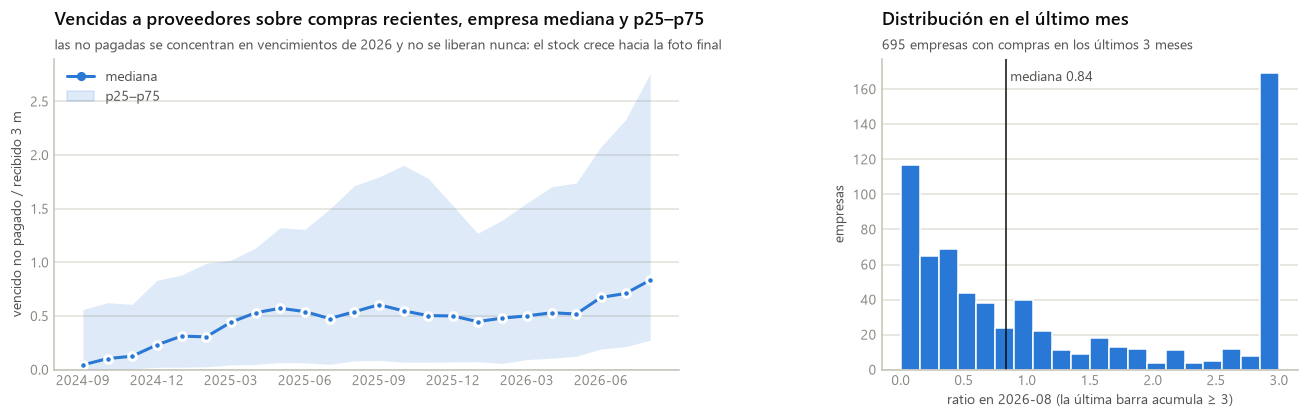

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
idx = month_ticks(ax, ov_q.index)
quantile_band(ax, idx, ov_q)
ax.set_ylim(0, None)
ax.set_ylabel("vencido no pagado / recibido 3 m")
title(ax, "Vencidas a proveedores sobre compras recientes, empresa mediana y p25–p75",
      "las no pagadas se concentran en vencimientos de 2026 y no se liberan nunca: el stock crece hacia la foto final")

ax = axes[1]
ax.hist(ov_last.clip(upper=3), bins=np.arange(0, 3.1, 0.15), color=SERIES[0], edgecolor=SURFACE, linewidth=1)
median_line(ax, ov_last.median(), f"mediana {ov_last.median():.2f}")
ax.set_xlabel("ratio en 2026-08 (la última barra acumula ≥ 3)")
ax.set_ylabel("empresas")
title(ax, "Distribución en el último mes", f"{len(ov_last)} empresas con compras en los últimos 3 meses")
fig.tight_layout(w_pad=3)
plt.show()

## 12. Servicio de deuda y coste implícito, desde los movimientos

`debt_repayment` e `interest_charge` cubren más empresas que `debt_products` (los préstamos intragrupo y los no conectados también pagan cuota). Dos proxies del plan:

- **Cobertura del servicio de deuda (DSCR)** = entradas operativas de los últimos 6 meses / (cuotas + intereses) de los últimos 6 meses. *Entradas operativas* = abonos con categoría `collection`, `bulk_collection`, `pos_settlement` o `cash_settlement` (con todos los abonos la mediana sale 42×: los barridos y transferencias lo inundan).
- **Coste implícito** = intereses de 12 meses / deuda viva (`outstanding` de `debt_products`). Es el número que el producto de refinanciación compara con el tipo justo.

In [39]:
svc = (tx[tx["category"].isin(["debt_repayment", "interest_charge"])]
         .assign(a=lambda d: -d["amount"])
         .groupby(["company_id", "month", "category"])["a"].sum().unstack("category")
         .reindex(columns=["debt_repayment", "interest_charge"]).fillna(0))
rep = svc["debt_repayment"].unstack().reindex(columns=FULL_MONTHS).fillna(0)
intr = svc["interest_charge"].unstack().reindex(index=rep.index, columns=FULL_MONTHS).fillna(0)
OPERATING_IN = ["collection", "bulk_collection", "pos_settlement", "cash_settlement"]      # abonos operativos, sin transferencias
infl = (tx[(tx["amount"] > 0) & tx["category"].isin(OPERATING_IN)].groupby(["company_id", "month"])["amount"].sum().unstack()
          .reindex(index=rep.index, columns=FULL_MONTHS).fillna(0))

service = rep + intr
svc_share = (service / infl.where(infl > 0)).where(service > 0)              # cuota / entradas del mes
svc_q = svc_share.quantile([.25, .5, .75]).T.set_axis(["p25", "p50", "p75"], axis=1)
svc_q["empresas con cuota"] = (service > 0).sum()

s6, i6 = service.iloc[:, -6:].sum(axis=1), infl.iloc[:, -6:].sum(axis=1)
dscr = (i6 / s6)[(service.iloc[:, -6:] > 0).sum(axis=1) >= 3]                # ≥ 3 meses con cuota en los últimos 6
outstanding = debt.groupby("company_id")["outstanding"].apply(lambda s: s.abs().sum())
i12 = intr.iloc[:, -12:].sum(axis=1)
cost = (i12 / outstanding.reindex(i12.index))[(i12 > 0) & (outstanding.reindex(i12.index) > 0)]
print(f"{len(rep)} empresas con cuota o intereses · DSCR calculable en {len(dscr)} · coste implícito en {len(cost)} "
      f"(mediana {cost.median():.1%} vs {dsc['annual_interest_rate_or_spread'].median():.1%} en los 87 contratos)")
pd.DataFrame({"DSCR 6 m": dscr.describe(percentiles=[.1, .25, .5, .75, .9]),
              "coste implícito": cost.describe(percentiles=[.1, .25, .5, .75, .9])}).round(2)

718 empresas con cuota o intereses · DSCR calculable en 400 · coste implícito en 196 (mediana 0.3% vs 3.0% en los 87 contratos)


,DSCR 6 m,coste implícito
count,400.00,196.00
mean,"3,519.78",0.82
std,"27,646.84",8.40
min,0.00,0.00
10%,1.35,0.00
25%,5.74,0.00
50%,21.09,0.00
75%,171.56,0.02
90%,"1,863.62",0.10
max,"517,140.29",115.78


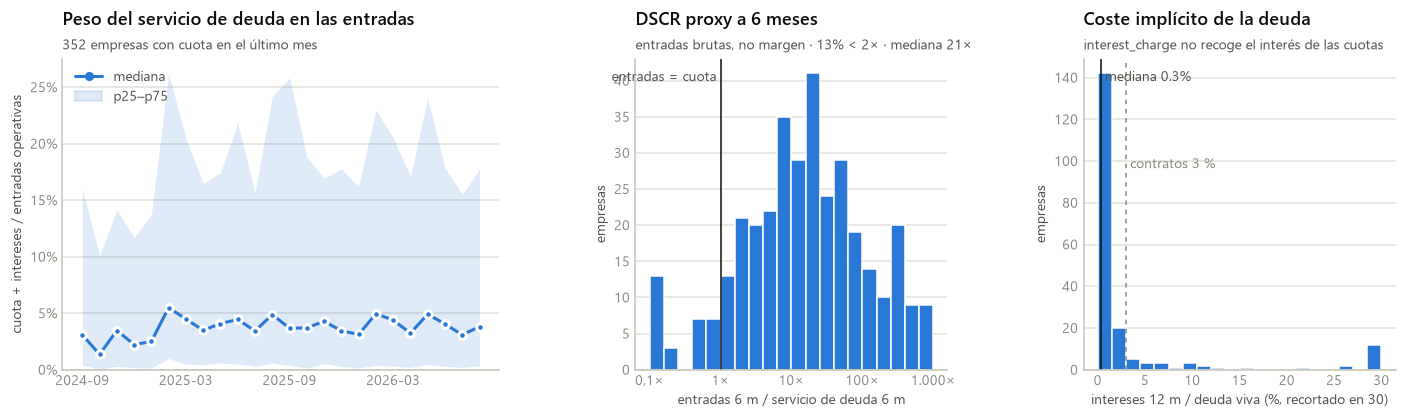

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), gridspec_kw={"width_ratios": [1.4, 1, 1]})

ax = axes[0]
idx = month_ticks(ax, svc_q.index, every=6)
quantile_band(ax, idx, svc_q)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, None)
ax.set_ylabel("cuota + intereses / entradas operativas")
title(ax, "Peso del servicio de deuda en las entradas", f"{int(svc_q['empresas con cuota'].iloc[-1])} empresas con cuota en el último mes")

ax = axes[1]
lg = np.log10(dscr.clip(0.1, 1000))
ax.hist(lg, bins=np.arange(-1, 3.1, 0.2), color=SERIES[0], edgecolor=SURFACE, linewidth=1)
ax.axvline(0, color=INK["primary"], linewidth=1)
ax.text(0, 0.96, "entradas = cuota ", transform=ax.get_xaxis_transform(), fontsize=9, color=INK["secondary"], va="top", ha="right")
ax.set_xticks([-1, 0, 1, 2, 3], ["0,1×", "1×", "10×", "100×", "1.000×"])
ax.set_xlabel("entradas 6 m / servicio de deuda 6 m")
ax.set_ylabel("empresas")
title(ax, "DSCR proxy a 6 meses", f"entradas brutas, no margen · {(dscr < 2).mean():.0%} < 2× · mediana {dscr.median():.0f}×")

ax = axes[2]
ax.hist(cost.clip(upper=0.3) * 100, bins=np.arange(0, 31, 1.5), color=SERIES[0], edgecolor=SURFACE, linewidth=1)
median_line(ax, cost.median() * 100, f"mediana {cost.median():.1%}")
ref = dsc["annual_interest_rate_or_spread"].median() * 100
ax.axvline(ref, color=INK["muted"], linewidth=1, linestyle=(0, (3, 3)))
ax.text(ref, 0.68, f" contratos {ref:.0f} %", transform=ax.get_xaxis_transform(), fontsize=9, color=INK["muted"], va="top")
ax.set_xlabel("intereses 12 m / deuda viva (%, recortado en 30)")
ax.set_ylabel("empresas")
title(ax, "Coste implícito de la deuda", "interest_charge no recoge el interés de las cuotas")
fig.tight_layout(w_pad=2.5)
plt.show()

## 13. Concentración de clientes y pérdida del cliente principal

Desde facturas emitidas con contraparte (99 %). Ventana móvil de 12 meses por empresa: cuota del mayor cliente y HHI. El *watch* del plan ("pérdida del cliente principal") se aproxima así: el cliente que era el mayor hace 3 meses (≥ 20 % de la facturación de 12 m **y recurrente**: factura en ≥ 6 de esos 12 meses) no tiene ninguna factura en los últimos 3. Sin la condición de recurrencia, un tercio de las empresas "pierde" su cliente cada mes: son clientes de una sola factura grande.

In [41]:
iss = inv[(inv["direction"] == "issued") & inv["counterparty_id"].notna() & inv["issuance_date"].notna()]
iss = iss.assign(month=iss["issuance_date"].dt.to_period("M"), a=iss["amount"].abs())
pc = (iss.groupby(["company_id", "counterparty_id", "month"])["a"].sum().unstack()
         .reindex(columns=FULL_MONTHS).fillna(0))
r12 = pc.T.rolling(12, min_periods=6).sum().T                        # facturado a cada cliente, últimos 12 meses
tot12 = r12.groupby(level="company_id").transform("sum")
share = (r12 / tot12.where(tot12 > 0))
top1 = share.groupby(level="company_id").max()
hhi = (share ** 2).groupby(level="company_id").sum(min_count=1)
n_clients = r12.gt(0).groupby(level="company_id").sum().where(top1.notna())

last3 = pc.T.rolling(3).sum().T
active12 = pc.gt(0).T.rolling(12, min_periods=6).sum().T                 # meses con factura de ese cliente en 12
lost = {}
for j in range(15, len(FULL_MONTHS)):
    s_prev = share.iloc[:, j - 3].dropna()
    top = s_prev.groupby(level="company_id").idxmax()
    key = pd.MultiIndex.from_tuples(top.tolist())
    recurrent = (s_prev.reindex(key).values >= 0.2) & (active12.iloc[:, j - 3].reindex(key).values >= 6)
    top = top[recurrent]
    billed = last3.reindex(pd.MultiIndex.from_tuples(top.tolist())).iloc[:, j]
    lost[FULL_MONTHS[j]] = pd.Series(billed.values == 0, index=top.index)
lost = pd.DataFrame(lost)

t1, hh, nc = top1.iloc[:, -1].dropna(), hhi.iloc[:, -1].dropna(), n_clients.iloc[:, -1].dropna()
print(f"{len(t1)} empresas con ≥ 6 meses de facturas emitidas · cliente principal mediana {t1.median():.0%} · "
      f"HHI mediana {hh.median():.2f} · clientes activos mediana {nc.median():.0f}")
pd.DataFrame({"cuota del mayor cliente": t1.describe(percentiles=[.1, .25, .5, .75, .9]),
              "HHI": hh.describe(percentiles=[.1, .25, .5, .75, .9]),
              "clientes activos 12 m": nc.describe(percentiles=[.1, .25, .5, .75, .9])}).round(2)

704 empresas con ≥ 6 meses de facturas emitidas · cliente principal mediana 56% · HHI mediana 0.42 · clientes activos mediana 20


,cuota del mayor cliente,HHI,clientes activos 12 m
count,704.00,704.00,704.00
mean,0.58,0.48,67.82
std,0.31,0.34,155.88
min,0.01,0.00,1.00
10%,0.15,0.06,2.00
25%,0.31,0.17,5.00
50%,0.56,0.42,20.00
75%,0.92,0.85,64.25
90%,1.00,1.00,157.00
max,1.00,1.00,"2,377.00"


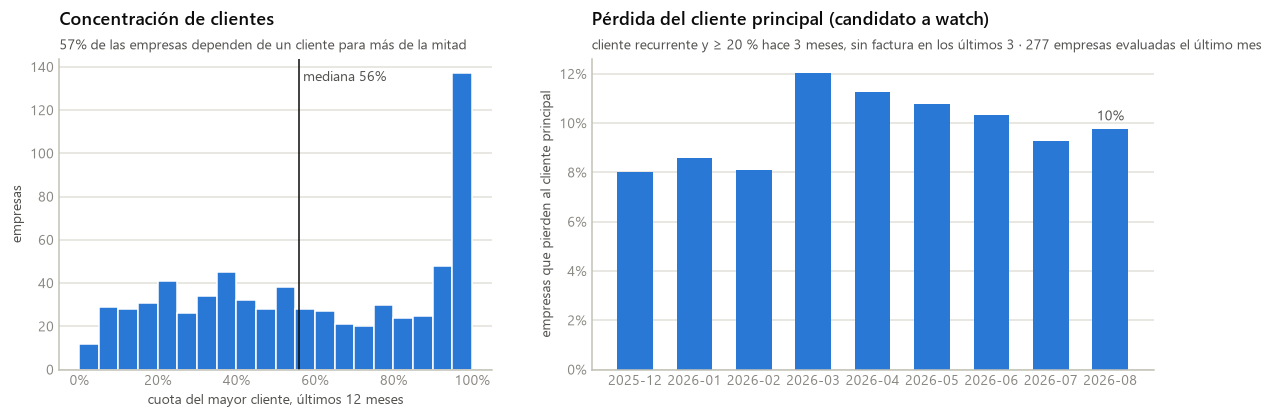

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1, 1.3]})

ax = axes[0]
ax.hist(t1, bins=np.linspace(0, 1, 21), color=SERIES[0], edgecolor=SURFACE, linewidth=1)
median_line(ax, t1.median(), f"mediana {t1.median():.0%}")
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("cuota del mayor cliente, últimos 12 meses")
ax.set_ylabel("empresas")
title(ax, "Concentración de clientes", f"{(t1 > 0.5).mean():.0%} de las empresas dependen de un cliente para más de la mitad")

ax = axes[1]
lost_share = lost.mean()
idx = month_ticks(ax, lost_share.index, every=1)
cols(ax, idx, lost_share.values)
cap_label(ax, idx[-1], lost_share.iloc[-1], f"{lost_share.iloc[-1]:.0%}")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("empresas que pierden al cliente principal")
title(ax, "Pérdida del cliente principal (candidato a watch)",
      f"cliente recurrente y ≥ 20 % hace 3 meses, sin factura en los últimos 3 · {int(lost.notna().sum().iloc[-1])} empresas evaluadas el último mes")
fig.tight_layout(w_pad=3)
plt.show()

## 14. Estacionalidad: bache o deterioro

El plan (§2) separa *bache* (caída de entradas explicada por el mismo mes del año anterior, o recuperada en ≤ 2 meses) de *deterioro* (persistente). Entradas del mes / entradas del mismo mes del año anterior, por empresa en EUR con ambos meses; y cuánto dura la caída más larga (> 30 %) de cada empresa.

In [43]:
ent = cm["entradas"].unstack("month").reindex(columns=FULL_MONTHS)
with np.errstate(divide="ignore", invalid="ignore"):
    yoy = np.log(ent.iloc[:, 12:] / ent.iloc[:, :12].values).replace([np.inf, -np.inf], np.nan)   # log(entradas_m / entradas_{m−12})
yoy_q = np.exp(yoy.quantile([.25, .5, .75]).T).set_axis(["p25", "p50", "p75"], axis=1)
yoy_q["empresas"] = yoy.notna().sum()

drop = yoy.lt(np.log(0.7)).astype(float).where(yoy.notna())
def longest_run(row):
    best = cur = 0
    for v in row:
        cur = cur + 1 if v == 1 else 0
        best = max(best, cur)
    return best
runs = drop.dropna(thresh=6).apply(longest_run, axis=1)
run_tab = pd.cut(runs, [-1, 0, 1, 2, 99], labels=["sin caída", "1 mes (bache)", "2 meses", "≥ 3 meses (deterioro)"]).value_counts().reindex(["sin caída", "1 mes (bache)", "2 meses", "≥ 3 meses (deterioro)"])
print(f"{len(runs)} empresas con ≥ 6 comparaciones interanuales · mediana interanual último mes {yoy_q['p50'].iloc[-1]:.0%}")
pd.DataFrame({"empresas": run_tab, "%": (run_tab / run_tab.sum() * 100).round(0)}).T

565 empresas con ≥ 6 comparaciones interanuales · mediana interanual último mes 108%


,sin caída,1 mes (bache),2 meses,≥ 3 meses (deterioro)
empresas,91.00,204.00,123.00,147.00
%,16.00,36.00,22.00,26.00


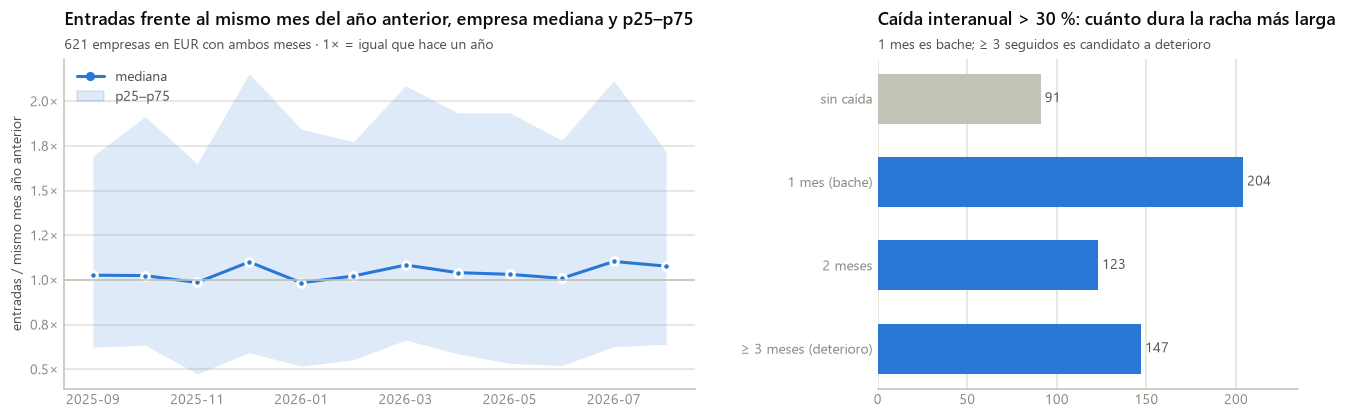

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
idx = month_ticks(ax, yoy_q.index, every=2)
quantile_band(ax, idx, yoy_q)
ax.axhline(1, color=INK["axis"], linewidth=1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}×"))
ax.set_ylabel("entradas / mismo mes año anterior")
title(ax, "Entradas frente al mismo mes del año anterior, empresa mediana y p25–p75",
      f"{int(yoy_q['empresas'].iloc[-1])} empresas en EUR con ambos meses · 1× = igual que hace un año")

ax = axes[1]
hbars(ax, run_tab.index.tolist(), run_tab.values, color=[GRAY, SERIES[0], SERIES[0], SERIES[0]], label_top=4, xfmt=PLAIN)
title(ax, "Caída interanual > 30 %: cuánto dura la racha más larga", "1 mes es bache; ≥ 3 seguidos es candidato a deterioro")
fig.tight_layout(w_pad=3)
plt.show()

## 15. Co-movimiento de señales y evento de deterioro (preview del slice #3)

La pregunta que decide modelo vs. reglas (plan §9–§10): ¿las señales se mueven **juntas** antes del estrés, como en Norden & Weber? Panel empresa-mes con cuatro señales ya calculadas: saldo corriente agregado < 0 (§9), vencidas / recibido 3 m (§11), uso de línea (§10) y entradas vs año anterior (§14).

1. Correlación de Spearman entre señales sobre todos los pares empresa-mes disponibles.
2. **Evento** con la regla del plan: ≥ 2 de 4 señales en rojo durante ≥ 2 meses seguidos. Rojo = saldo < 0 · vencidas > 50 % de las compras de 3 m · uso de línea > 80 % · entradas < 70 % del año anterior. Y la vista de *event study*: cómo se comporta cada señal (en z-score) desde 6 meses antes hasta 3 después del inicio del evento. Si las curvas ya se inclinan antes de t = 0, hay anticipación que medir.

In [45]:
comp_bal = eom_all.groupby(chk_company.reindex(eom_all.index).values).sum()
comp_act = active_all.groupby(chk_company.reindex(active_all.index).values).any()
bal_neg = comp_bal.lt(0).astype(float).where(comp_act)

sig = pd.concat({
    "saldo < 0": bal_neg.stack(),
    "vencidas / recibido 3m": overdue_ratio.stack(),
    "uso de línea": usage.stack(),
    "entradas vs año ant. (log)": yoy.stack(),
}, axis=1)
sig.index = sig.index.set_names(["company_id", "month"])
corr = sig.corr(method="spearman")
n_pairs = pd.DataFrame({a: {b: int(sig[[a, b]].dropna().shape[0]) for b in sig.columns} for a in sig.columns})

red = pd.DataFrame({
    "saldo < 0": sig["saldo < 0"] == 1,
    "vencidas": sig["vencidas / recibido 3m"] > 0.5,
    "uso de línea": sig["uso de línea"] > 0.8,
    "entradas": sig["entradas vs año ant. (log)"] < np.log(0.7),
})
n_red = red.sum(axis=1)
hot = (n_red >= 2).unstack("month").reindex(columns=FULL_MONTHS).fillna(False)
run2 = hot & hot.shift(1, axis=1).fillna(False)                       # rojo en m y m−1
start = run2 & ~run2.shift(1, axis=1).fillna(False)                   # primer mes de cada racha (el evento empieza en m−1)
events = [(r, j - 1) for r, j in np.argwhere(start.values)]
print(f"{len(sig):,} pares empresa-mes · {(n_red >= 2).mean():.1%} con ≥ 2 señales en rojo · "
      f"{len(events)} eventos (≥ 2 rojas, ≥ 2 meses) en {start.any(axis=1).sum()} empresas")
print("pares usados por correlación:"); display(n_pairs)
corr.round(2)

30,732 pares empresa-mes · 4.0% con ≥ 2 señales en rojo · 222 eventos (≥ 2 rojas, ≥ 2 meses) en 177 empresas
pares usados por correlación:


,saldo < 0,vencidas / recibido 3m,uso de línea,entradas vs año ant. (log)
saldo < 0,21814,12194,2022,6147
vencidas / recibido 3m,12194,14397,1208,3725
uso de línea,2022,1208,2062,773
entradas vs año ant. (log),6147,3725,773,6172


,saldo < 0,vencidas / recibido 3m,uso de línea,entradas vs año ant. (log)
saldo < 0,1.00,0.02,0.12,-0.03
vencidas / recibido 3m,0.02,1.00,-0.14,-0.11
uso de línea,0.12,-0.14,1.00,-0.01
entradas vs año ant. (log),-0.03,-0.11,-0.01,1.00


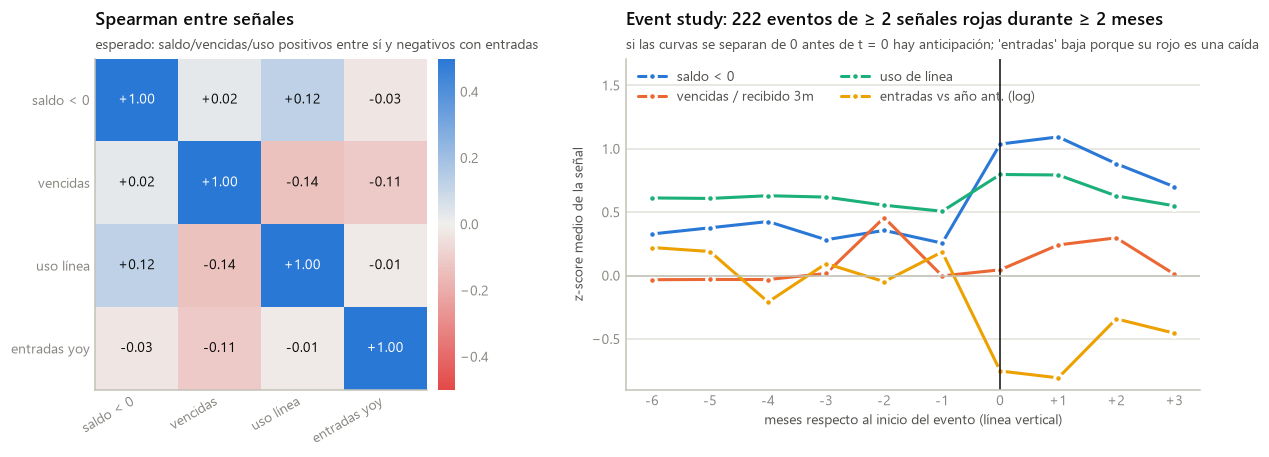

In [46]:
CMAP_DIV = LinearSegmentedColormap.from_list("xray_div", [DIV["neg"], DIV["mid"], DIV["pos"]])
z = (sig - sig.mean()) / sig.std()
mats = {c: z[c].unstack("month").reindex(index=hot.index, columns=FULL_MONTHS).values for c in z.columns}
offsets = list(range(-6, 4))
profile = pd.DataFrame(index=offsets, columns=z.columns, dtype=float)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for c, m in mats.items():
        for k in offsets:
            vals = [m[r, j + k] for r, j in events if 0 <= j + k < len(FULL_MONTHS)]
            profile.loc[k, c] = np.nanmean(vals) if vals else np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.5]})

ax = axes[0]
im = ax.imshow(corr.values, cmap=CMAP_DIV, vmin=-0.5, vmax=0.5)
short = ["saldo < 0", "vencidas", "uso línea", "entradas yoy"]
ax.set_xticks(range(4), short, rotation=30, ha="right")
ax.set_yticks(range(4), short)
ax.grid(False)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.values[i, j]:+.2f}", ha="center", va="center", fontsize=9,
                color=INK["primary"] if abs(corr.values[i, j]) < 0.35 else SURFACE)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
title(ax, "Spearman entre señales", "esperado: saldo/vencidas/uso positivos entre sí y negativos con entradas")

ax = axes[1]
for i, c in enumerate(profile.columns):
    ax.plot(offsets, profile[c].values, color=SERIES[i], label=c, **marker(markersize=5))
ax.axvline(0, color=INK["primary"], linewidth=1)
ax.axhline(0, color=INK["axis"], linewidth=1)
ax.set_xticks(offsets, [f"{k:+d}" if k else "0" for k in offsets])
ax.set_xlabel("meses respecto al inicio del evento (línea vertical)")
ax.set_ylabel("z-score medio de la señal")
ax.legend(loc="upper left", ncol=2)
lo, hi = ax.get_ylim()
ax.set_ylim(lo, hi + 0.25 * (hi - lo))
title(ax, f"Event study: {len(events)} eventos de ≥ 2 señales rojas durante ≥ 2 meses",
      "si las curvas se separan de 0 antes de t = 0 hay anticipación; 'entradas' baja porque su rojo es una caída")
fig.tight_layout(w_pad=3)
plt.show()

## 16. Lo que hay que llevarse

**Del dataset (§1–§8)**

- **Cobertura desigual**: mediana 19 meses, 25 % con ≤ 10. Features con ventanas 3/6 y que degraden bien (§2).
- **Sin sector ni país útil**: pares por tamaño y flujos (§3).
- **Importes en moneda local sin convertir** y volumen bruto concentrado en diez empresas con barridos de 10⁹ €/mes: nunca sumar en bruto; normalizar por empresa (medianas, ratios) y filtrar/convertir moneda (§4–5).
- **Movimientos**: categorías del banco suficientes para DSCR y coste de deuda; contraparte solo al 10 % (§4).
- **Facturas**: dirección por signo; `overdue` sin fecha real de pago; un tercio de las pagadas se cobra/paga después del vencimiento (§5).
- **Deuda**: 378 empresas; 87 préstamos con tipo; el uso de líneas de crédito es bimodal (sin disponer o agotadas) (§6).
- **Saldos**: solo foto final → se reconstruye hacia atrás; una de cada cinco cuentas corrientes está a 0 € (§7–8).

**De las señales (§9–§15)** — cada punto es una decisión para `xray.features` / `xray.labels`:

- **La reconstrucción de saldo tiene deriva**: las cuentas en negativo pasan del 10 % al 2 % hacia la foto final, igual en la cohorte fija y con solo `booked`. No es composición ni pendientes: es el generador o movimientos que faltan. 120 cuentas arrancan por debajo de −100 K. → La señal "meses en negativo" debe normalizarse por fecha (rango dentro del mes, o comparar con la mediana del mes), no usarse en bruto (§9).
- **Uso de línea reconstruible en 137 empresas** (dispuesto = −saldo). Bimodal y ruidoso: las mayores subidas a 6 meses son escalones de una disposición, no rampas. → Feature válido, pero con `n_lines` y meses de historia como marca de confianza (§10).
- **Vencidas a proveedores**: el 44 % de las empresas tiene vencido más de 3 meses de compras en el último mes; el stock crece hacia la foto porque las no pagadas se concentran en vencimientos de 2026. → Ratio útil en corte transversal; en el tiempo, comparar con la mediana del mes (§11).
- **DSCR sobre entradas operativas brutas** sale alto (mediana ~20×): discrimina la cola, no el centro. **`interest_charge` no recoge el interés de las cuotas** (coste implícito mediana 0,3 % vs 3 % en contratos). → El coste de la deuda tiene que salir de `debt_schedule_config` y de la cuota, no de esa categoría (§12).
- **Concentración de clientes alta**: el 57 % depende de un cliente para más de la mitad de la facturación; la pérdida de un cliente principal *recurrente* afecta al 8–12 % de las empresas cada mes. → Watch viable, con la condición de recurrencia (§13).
- **Estacionalidad**: la interanual mediana es ≈ 1× todo el año; el 26 % de las empresas encadena ≥ 3 meses de caída > 30 % y el 36 % solo uno. → La regla bache/deterioro separa bien (§14).
- **Co-movimiento casi nulo**: Spearman entre señales |ρ| ≤ 0,14 y ninguna señal se inclina antes de t = 0 en el event study (222 eventos, 177 empresas). **El dataset no reproduce a Norden & Weber en esta primera pasada.** → Hay que repetirlo con las features definitivas (slice #3); si se confirma, el score va con reglas calibradas (plan B, `docs/plan.md` §9) y se dice en el pitch (§15).

Siguiente notebook: `02_features_*.ipynb` sobre `xray.features` cuando exista la tabla `features(company_id, month)`; los chequeos de §15 se rehacen ahí como slice #3.
